# Практична робота № 4 — Пороги, вартість помилок і прийняття рішень у класифікації

**Набір даних:** Breast Cancer Wisconsin (Diagnostic) (`sklearn.datasets.load_breast_cancer`), той самий, що в практичній роботі № 1.
**Позитивний клас** $y=1$ — **злоякісне** новоутворення.

**Мета роботи.** Не шукати кращий алгоритм, а *спроєктувати рішення навколо вже зафіксованого класифікатора*:
отримати чесні OOF-бали, оцінити наслідки помилок, проаналізувати сітку порогів, врахувати ресурсне обмеження,
перевірити калібрування й стійкість вибору, оформити політику як компонент із конфігурацією та тестами
і один раз перевірити її на тестовій вибірці.

> **Логіка роботи:** зафіксована модель → OOF-бали → наслідки помилок → сітка порогів → обмеження → калібрування → політика → одноразовий test.

> **Важливо про вартості.** Усі вартості помилок у цій роботі — **сценарні (експертні) припущення навчального завдання**, а не виміряні дані.
> Система ШІ не є джерелом реальної вартості помилки; для реального впровадження їх треба узгодити з клініцистами та власниками процесу.

In [1]:
import json
import subprocess
import sys
from datetime import date
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.datasets import load_breast_cancer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (brier_score_loss, confusion_matrix, f1_score, log_loss,
                             precision_score, recall_score, roc_auc_score)
from sklearn.model_selection import StratifiedKFold, cross_val_predict, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

RANDOM_STATE = 42
FIG = Path("../figures")
RES = Path("../results")
POL = Path("../policy")
for p in (FIG, RES, POL):
    p.mkdir(exist_ok=True)

plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25
pd.set_option("display.width", 170)
pd.set_option("display.max_columns", 40)

# Компонент політики завантажуємо з файлу (код політики лежить окремо від notebook)
sys.path.insert(0, str(POL.resolve()))
import decision_policy as dp

C_BENIGN, C_MALIGN, C_RED, C_GREY, C_PURPLE = "#4f81bd", "#c0504d", "#c0504d", "#7f7f7f", "#8064a2"
print("scikit-learn / numpy / pandas версії:", __import__("sklearn").__version__, np.__version__, pd.__version__)

scikit-learn / numpy / pandas версії: 1.9.0 2.2.3 3.0.5


## 1. Опис контексту рішення

Набір даних — публічний навчальний (WDBC), тому *клінічний сценарій нижче є гіпотетичною навчальною постановкою*,
яка надає прогнозу моделі конкретну дію. Це не реальний клінічний протокол і не медична рекомендація.

**Сценарій: тріаж результатів цитологічного дослідження (FNA) новоутворення молочної залози.**
Для кожного пацієнта з пальпованим/УЗД-виявленим вузлом виконано тонкоголкову аспіраційну біопсію (FNA);
з оцифрованого зображення обчислено 30 морфометричних ознак клітинних ядер. Модель повертає оцінку ризику злоякісності,
а політика перетворює її на організаційну дію.

| Питання завдання | Відповідь у цьому сценарії |
|---|---|
| 1. Що означають класи | $y=0$ — доброякісне новоутворення; $y=1$ — **злоякісне**. (У `sklearn` кодування протилежне: `0=malignant`, тому в роботі $y = 1-\text{target}$.) |
| 2. Яку дію запускає $\hat y=1$ | Направлення на **гістологічну (core-needle) біопсію** та консультацію онколога. |
| 3. Що відбувається за $\hat y=0$ | **Планове спостереження**: контрольне УЗД приблизно через 6 місяців (сценарне припущення). |
| 4. Хто виконує дію | Програмний компонент формує рекомендацію в системі маршрутизації пацієнтів; направлення підтверджує лікар, біопсію виконує радіолог/хірург; консультацію веде онколог. |
| 5. Коли доступні ознаки | Після FNA й оцифрування зображення — до ухвалення рішення про подальше обстеження (ознаки не містять майбутньої інформації). |
| 6. Через який час відома правильна мітка | Для $\hat y=1$ — гістологічний висновок за кілька днів — два тижні після біопсії (орієнтир, сценарне припущення). Для $\hat y=0$ мітка з'являється лише на контролі через ~6 міс. або якщо пухлина проявиться раніше — **мітки для моніторингу приходять з великою затримкою і лише частково** (селективні мітки). |

**Наслідки помилок (окремо).**

* **FP** (доброякісне → направлено на біопсію): зайва інвазивна процедура, ризик ускладнень (гематома, біль), стрес пацієнтки, витрата часу радіолога/патолога, зайняті «слоти» біопсії. Наслідок оборотний, вимірюється в кількості зайвих біопсій і годин персоналу.
* **FN** (злоякісне → планове спостереження): **пропущена злоякісна пухлина**; діагноз затримується на місяці до контрольного обстеження, пухлина може прогресувати, лікування розпочнеться пізніше. Наслідок потенційно невідворотний; вимірюється в кількості пропущених випадків і місяцях затримки діагнозу.

Оскільки наслідки мають різну природу й різні одиниці, «FN гірше за FP» саме по собі нічого не визначає — далі це відношення перетворюється на число (сценарій $c_{FN}/c_{FP}$) і перевіряється чутливість рішення до нього.

## 2. Фіксація моделі та експериментального протоколу

Усе нижче фіксується **до** аналізу порогів і більше не змінюється.

| Елемент | Значення |
|---|---|
| Набір даних, target | `load_breast_cancer(as_frame=True)`; $y = 1 - \text{target}_{sklearn}$, позитивний клас $y=1$ = malignant |
| Ознаки | 30 числових, імена `<property>_<mean\|se\|worst>` (як у практичній № 1) |
| Train/test split | `train_test_split(X, target, test_size=0.2, stratify=target, random_state=42)` — **той самий, що в практичній № 1** (стратифікація за початковим кодуванням target) |
| Preprocessing | `StandardScaler` **усередині** `Pipeline` (щоб масштаб навчався тільки на train-частині кожного fold) |
| Модель | `LogisticRegression(C=1.0, max_iter=5000, random_state=42)` — без пошуку алгоритму й гіперпараметрів |
| Бал | `predict_proba[:, 1]` — оцінка ймовірності **злоякісного** класу (порядок колонок перевіряється через `classes_`) |
| OOF-схема | `StratifiedKFold(n_splits=5, shuffle=True, random_state=42)` на $D_{train}$ |
| Калібрування (кандидат) | `CalibratedClassifierCV(method="sigmoid", cv=3)` всередині того ж зовнішнього CV; ізотонічне — додатково для порівняння |
| $D_{test}$ | Не використовується для жодних рішень до розділу 13 |

In [2]:
data = load_breast_cancer(as_frame=True)
assert list(data.target_names) == ["malignant", "benign"]   # sklearn: 0 = malignant, 1 = benign

df = data.frame.copy().rename(columns={"target": "diagnosis"})


def to_snake(col):
    # <property>_<mean|se|worst> — той самий код, що в практичній № 1
    parts = col.split()
    if parts[0] in ("mean", "worst"):
        return "_".join(parts[1:]) + "_" + parts[0]
    if parts[-1] == "error":
        return "_".join(parts[:-1]) + "_se"
    return col


df.columns = [c if c == "diagnosis" else to_snake(c) for c in df.columns]
FEATURES = [c for c in df.columns if c != "diagnosis"]
print(df.shape, "| приклади назв ознак:", FEATURES[:2], FEATURES[-2:])

X = df[FEATURES]
target_sk = df["diagnosis"]                      # 0 = malignant, 1 = benign

# Split — ідентично практичній № 1 (ті самі аргументи), далі інвертуємо мітки
X_train, X_test, t_train, t_test = train_test_split(
    X, target_sk, test_size=0.2, stratify=target_sk, random_state=RANDOM_STATE
)
y_train, y_test = 1 - t_train, 1 - t_test         # 1 = malignant (позитивний клас)

# Перевірка відтворення: незалежний повторний split за індексами збігається
idx_train2, idx_test2 = train_test_split(
    df.index.to_numpy(), test_size=0.2, stratify=target_sk, random_state=RANDOM_STATE
)
assert set(idx_train2) == set(X_train.index) and set(idx_test2) == set(X_test.index)
assert set(X_train.index).isdisjoint(X_test.index) and len(X_train) + len(X_test) == len(df)
assert (X_train.index == y_train.index).all()

# Додатково звіряємо з файлом практичної № 1 (лише читання), якщо він є
p1 = Path("../../practical01/data/split_processed.npz")
if p1.exists():
    ref = np.load(p1, allow_pickle=True)
    assert np.array_equal(ref["y_train"], t_train.to_numpy()) and np.array_equal(ref["y_test"], t_test.to_numpy())
    print("Збіг з practical01/data/split_processed.npz (мітки train/test у тому самому порядку): OK")

print(f"train: {len(X_train)} об'єктів, частка malignant = {y_train.mean():.4f} ({y_train.sum()} злоякісних)")
print(f"test : {len(X_test)} об'єктів, частка malignant = {y_test.mean():.4f} ({y_test.sum()} злоякісних)")
print("Загалом malignant:", int((1 - target_sk).sum()), "з", len(df))

split_df = pd.concat([
    pd.DataFrame({"object_id": X_train.index, "subset": "train"}),
    pd.DataFrame({"object_id": X_test.index, "subset": "test"}),
])
split_df.to_csv(RES / "split_indices.csv", index=False)
print("Збережено results/split_indices.csv:", split_df.shape)

(569, 31) | приклади назв ознак: ['radius_mean', 'texture_mean'] ['symmetry_worst', 'fractal_dimension_worst']
Збіг з practical01/data/split_processed.npz (мітки train/test у тому самому порядку): OK
train: 455 об'єктів, частка malignant = 0.3736 (170 злоякісних)
test : 114 об'єктів, частка malignant = 0.3684 (42 злоякісних)
Загалом malignant: 212 з 569
Збережено results/split_indices.csv: (569, 2)


In [3]:
def make_pipeline():
    return Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(C=1.0, max_iter=5000, random_state=RANDOM_STATE)),
    ])


pipe = make_pipeline()

# Перевіряємо порядок класів: колонка 1 predict_proba має відповідати y = 1 (malignant)
probe = clone(pipe).fit(X_train, y_train)
assert list(probe.classes_) == [0, 1]
pos_col = list(probe.classes_).index(1)
assert pos_col == 1
p_probe = probe.predict_proba(X_train)[:, pos_col]
assert p_probe[y_train.to_numpy() == 1].mean() > 0.9 > 0.1 > p_probe[y_train.to_numpy() == 0].mean()
print("classes_ =", probe.classes_, "-> predict_proba[:, 1] — ймовірність злоякісного класу")

classes_ = [0 1] -> predict_proba[:, 1] — ймовірність злоякісного класу


In [4]:
outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
N_TRAIN = len(X_train)

score_raw = np.full(N_TRAIN, np.nan)
score_sig = np.full(N_TRAIN, np.nan)
score_iso = np.full(N_TRAIN, np.nan)
fold_id = np.full(N_TRAIN, -1)
times_predicted = np.zeros(N_TRAIN, dtype=int)

for k, (tr, va) in enumerate(outer_cv.split(X_train, y_train)):
    assert set(tr).isdisjoint(va)                      # модель не бачить об'єкти свого fold
    Xtr, ytr, Xva = X_train.iloc[tr], y_train.iloc[tr], X_train.iloc[va]

    base = clone(pipe).fit(Xtr, ytr)
    assert list(base.classes_) == [0, 1]
    score_raw[va] = base.predict_proba(Xva)[:, 1]

    # Калібратор навчається ВСЕРЕДИНІ Xtr (внутрішній CV=3), fold va йому не доступний
    sig = CalibratedClassifierCV(estimator=clone(pipe), method="sigmoid", cv=3).fit(Xtr, ytr)
    score_sig[va] = sig.predict_proba(Xva)[:, 1]
    iso = CalibratedClassifierCV(estimator=clone(pipe), method="isotonic", cv=3).fit(Xtr, ytr)
    score_iso[va] = iso.predict_proba(Xva)[:, 1]

    fold_id[va] = k
    times_predicted[va] += 1
    print(f"fold {k}: навчання {len(tr)}, оцінювання {len(va)}, malignant у fold = {y_train.iloc[va].mean():.3f}")

# Кожний об'єкт має рівно один OOF-прогноз
assert (times_predicted == 1).all() and (fold_id >= 0).all()
assert not np.isnan(score_raw).any() and not np.isnan(score_sig).any() and not np.isnan(score_iso).any()

# Крос-перевірка: ручний цикл дає те саме, що cross_val_predict (методичка, лістинг 1)
ref_raw = cross_val_predict(clone(pipe), X_train, y_train, cv=outer_cv, method="predict_proba")[:, 1]
ref_sig = cross_val_predict(CalibratedClassifierCV(estimator=clone(pipe), method="sigmoid", cv=3),
                            X_train, y_train, cv=outer_cv, method="predict_proba")[:, 1]
assert np.allclose(ref_raw, score_raw) and np.allclose(ref_sig, score_sig)
print("\nКожен з", N_TRAIN, "об'єктів має рівно один OOF-прогноз; збіг із cross_val_predict: OK")
print("Діапазон score_raw:", score_raw.min(), "...", score_raw.max())
print("Унікальних значень score_raw:", np.unique(score_raw).size, "з", N_TRAIN)

oof = pd.DataFrame({
    "object_id": X_train.index.to_numpy(),
    "y_true": y_train.to_numpy(),
    "score_raw": score_raw,
    "score_calibrated": score_sig,        # sigmoid (CalibratedClassifierCV, cv=3)
    "fold": fold_id,
})
oof.to_csv(RES / "oof_predictions.csv", index=False)
print("Збережено results/oof_predictions.csv:", oof.shape)
oof.head()

fold 0: навчання 364, оцінювання 91, malignant у fold = 0.374


fold 1: навчання 364, оцінювання 91, malignant у fold = 0.374


fold 2: навчання 364, оцінювання 91, malignant у fold = 0.374


fold 3: навчання 364, оцінювання 91, malignant у fold = 0.374


fold 4: навчання 364, оцінювання 91, malignant у fold = 0.374



Кожен з 455 об'єктів має рівно один OOF-прогноз; збіг із cross_val_predict: OK
Діапазон score_raw: 9.995426804968586e-09 ... 1.0
Унікальних значень score_raw: 455 з 455
Збережено results/oof_predictions.csv: (455, 5)


,object_id,y_true,score_raw,score_calibrated,fold
0,546,0,0.000054,0.002401,0
1,432,1,0.999983,0.997600,3
2,174,0,0.000006,0.000889,4
3,221,0,0.012496,0.083933,2
4,289,0,0.000587,0.013735,3


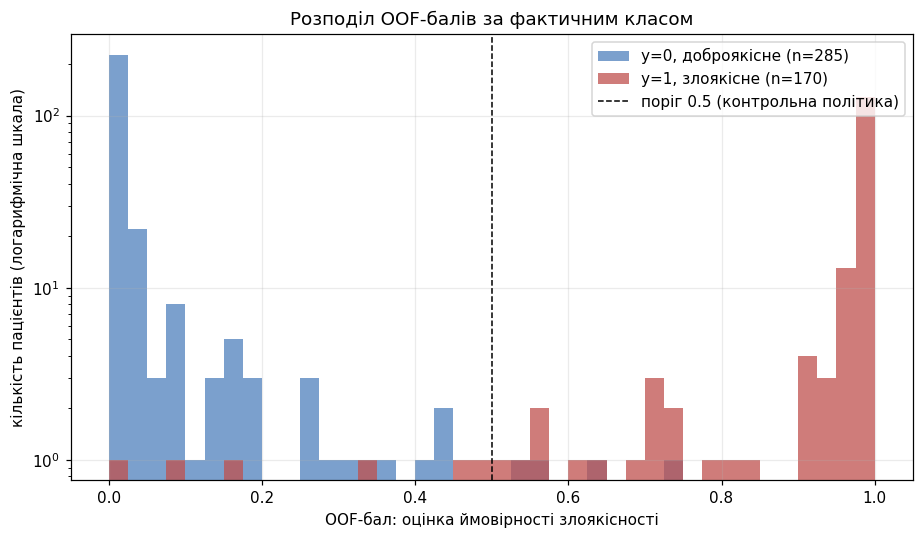

In [5]:
y = oof["y_true"].to_numpy()
S_RAW = oof["score_raw"].to_numpy()
S_SIG = oof["score_calibrated"].to_numpy()
S_ISO = score_iso
N, N_POS = len(y), int(y.sum())

fig, ax = plt.subplots(figsize=(8.5, 5))
bins = np.linspace(0, 1, 41)
ax.hist(S_RAW[y == 0], bins=bins, alpha=0.75, color=C_BENIGN, label=f"y=0, доброякісне (n={int((y==0).sum())})")
ax.hist(S_RAW[y == 1], bins=bins, alpha=0.75, color=C_MALIGN, label=f"y=1, злоякісне (n={N_POS})")
ax.axvline(0.5, color="black", ls="--", lw=1, label="поріг 0.5 (контрольна політика)")
ax.set_yscale("log")
ax.set_xlabel("OOF-бал: оцінка ймовірності злоякісності")
ax.set_ylabel("кількість пацієнтів (логарифмічна шкала)")
ax.set_title("Розподіл OOF-балів за фактичним класом")
ax.legend()
fig.tight_layout()
fig.savefig(FIG / "01_score_distribution.png")
plt.show()

**Інтерпретація рис. 1.** Розподіли двох класів майже не перекриваються: більшість доброякісних випадків має бал, близький до 0, більшість злоякісних — близький до 1.
Логарифмічна шкала по осі $Y$ потрібна, щоб побачити «хвости»: саме невелика кількість об'єктів у середній зоні (приблизно 0,05–0,95)
визначає, скільки помилок допускає будь-який поріг. Сильне розділення класів — властивість цього набору даних і лінійної моделі
(ROC-AUC OOF ≈ 0,995, розділ 8); воно робить вибір порога чутливим до окремих об'єктів, що буде видно в розділі 9.

## 3. Контрольна політика (baseline)

Базова політика: $\hat y = 1 \iff s \ge 0{,}5$, де $s$ — OOF-бал `predict_proba` логістичної регресії. Це **прозорий контрольний поріг**
(значення за замовчуванням класифікатора), а не твердження, що він правильний. $D_{test}$ тут не використовується.

In [6]:
def evaluate_threshold(y_true, score, t):
    # Правило: рішення ŷ = 1  <=>  score >= t
    y_pred = (np.asarray(score) >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    return {
        "threshold": t, "tn": int(tn), "fp": int(fp), "fn": int(fn), "tp": int(tp),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "q": y_pred.mean(),
    }


T_BASE = 0.5
base = evaluate_threshold(y, S_RAW, T_BASE)
cm = pd.DataFrame([[base["tn"], base["fp"]], [base["fn"], base["tp"]]],
                  index=["факт y=0 (доброякісне)", "факт y=1 (злоякісне)"],
                  columns=["ŷ=0 (спостереження)", "ŷ=1 (біопсія)"])
print("Матриця помилок, поріг 0.5, OOF (n =", N, "):")
print(cm.to_string())
print(f"\nPrecision = {base['precision']:.3f}   Recall = {base['recall']:.3f}   F1 = {base['f1']:.3f}")
print(f"q(0.5) = частка біопсій = {base['q']:.4f}  (частка злоякісних серед пацієнтів = {N_POS / N:.4f})")
print(f"На 1000 пацієнтів: біопсій {1000 * base['q']:.0f}, зайвих біопсій (FP) {1000 * base['fp'] / N:.1f}, "
      f"пропущених злоякісних (FN) {1000 * base['fn'] / N:.1f}")

Матриця помилок, поріг 0.5, OOF (n = 455 ):
                        ŷ=0 (спостереження)  ŷ=1 (біопсія)
факт y=0 (доброякісне)                  281              4
факт y=1 (злоякісне)                      6            164

Precision = 0.976   Recall = 0.965   F1 = 0.970
q(0.5) = частка біопсій = 0.3692  (частка злоякісних серед пацієнтів = 0.3736)
На 1000 пацієнтів: біопсій 369, зайвих біопсій (FP) 8.8, пропущених злоякісних (FN) 13.2


**Прикладна інтерпретація baseline.** За порогу 0,5 система направляє на біопсію 168 з 455 пацієнтів (369 на 1000): 164 справді злоякісних і 4 зайві (FP ≈ 8,8 на 1000).
Пропущено 6 злоякісних випадків (FN ≈ 13,2 на 1000), які отримали б планове спостереження й затримку діагнозу на місяці.
Precision = 0,976, Recall = 0,965, F1 = 0,970 — це високі показники, але вони нічого не говорять про *ціну* шести пропущених
випадків. Частка біопсій $q=0{,}369$ близька до частки злоякісних серед пацієнтів (0,374): за такої політики система майже не «переплачує» біопсіями.
Чи достатньо цього, залежить від співвідношення вартостей FN і FP (розділи 4–6).

## 4. Матриця вартостей і сценарії

| Комірка | Фактичний стан | Рішення системи | Операційна дія | Можливий наслідок | Одиниця вимірювання |
|---|---|---|---|---|---|
| **TN** | доброякісне | $\hat y=0$ | планове спостереження | пацієнтка не зазнає зайвих втручань; ресурси не витрачені | кількість уникнених біопсій |
| **FP** | доброякісне | $\hat y=1$ | зайва core-needle біопсія + консультація онколога | інвазивна процедура без потреби, стрес, час радіолога й патолога, зайнятий слот | зайві біопсії; умовні одиниці вартості |
| **FN** | злоякісне | $\hat y=0$ | спостереження (контроль ~через 6 міс.) | **пропущена злоякісна пухлина**, затримка діагнозу на місяці, ризик прогресування | пропущені випадки; місяці затримки діагнозу |
| **TP** | злоякісне | $\hat y=1$ | біопсія + консультація онколога | своєчасний діагноз і початок лікування (виправдана процедура) | своєчасно діагностовані випадки |

Вартість правильних рішень (TN, TP) прийнято рівною 0 *у додатковому розумінні*: TP також потребує біопсії, але вона була б потрібна
за будь-якого правильного процесу, тому в порівнянні політик не враховується. Загальна вартість політики:

$$C(t) = c_{FP}\cdot FP(t) + c_{FN}\cdot FN(t), \qquad \text{нормована вартість}= C(t)/n .$$

Одиниця вартості: **1 умовна одиниця = вартість однієї зайвої біопсії** ($c_{FP}=1$: процедура + стрес + витрати персоналу).
Для каліброваного бала байєсівський оптимальний поріг мінімізує очікувану вартість при $t^* = \dfrac{c_{FP}}{c_{FP}+c_{FN}}$.

| Сценарій | $c_{FN}/c_{FP}$ | Природа оцінки | Аргумент |
|---|---|---|---|
| **Контрольний** | 1 | суто сценарна | Помилки однаково «дорогі»; опорна точка для порівняння ($t^*=0{,}5$). |
| **Реалістичний (основний)** | 10 | **експертна гіпотеза студента, потребує погодження з клініцистами** | Пропущена злоякісна пухлина означає затримку діагнозу на місяці й гірший прогноз; зайва біопсія — оборотна. Порядок «одна затримка ≈ десять зайвих біопсій» вибрано як правдоподібний, але не виміряний. |
| **Стресовий** | 50 | суто сценарна | Верхня межа «дуже дорогого FN»; перевіряє, чи змінює рішення подальше зростання ціни помилки. |

У розділі 9 відношення змінюється неперервно в діапазоні 1…100, тому вибір 10 не є єдиною опорою висновків.

In [7]:
C_FP = 1.0
SCENARIOS = {"control": 1.0, "realistic": 10.0, "stress": 50.0}       # відношення c_FN / c_FP
SC_UA = {"control": "контрольний (1)", "realistic": "реалістичний (10)", "stress": "стресовий (50)"}
SC_COLOR = {"control": C_GREY, "realistic": C_MALIGN, "stress": C_PURPLE}
T_STAR = {k: C_FP / (C_FP + r * C_FP) for k, r in SCENARIOS.items()}   # теоретичний поріг для каліброваного бала

print(pd.DataFrame({
    "c_FP": C_FP, "c_FN": [r * C_FP for r in SCENARIOS.values()],
    "c_FN/c_FP": list(SCENARIOS.values()),
    "t* = c_FP/(c_FP+c_FN)": [round(v, 4) for v in T_STAR.values()],
}, index=[SC_UA[k] for k in SCENARIOS]).to_string())

QUOTA = 0.40            # жорстка квота: не більше 40% пацієнтів на біопсію за період
print("\nРесурсне обмеження: q(t) <= ", QUOTA, "(жорстка квота на біопсії)")

                   c_FP  c_FN  c_FN/c_FP  t* = c_FP/(c_FP+c_FN)
контрольний (1)     1.0   1.0        1.0                 0.5000
реалістичний (10)   1.0  10.0       10.0                 0.0909
стресовий (50)      1.0  50.0       50.0                 0.0196

Ресурсне обмеження: q(t) <=  0.4 (жорстка квота на біопсії)


## 5. Аналіз сітки порогів

Сітка порогів — об'єднання: рівномірної сітки $0{,}001, 0{,}002, \dots, 0{,}999$ (999 точок), логарифмічних малих порогів
$10^{-6}\ldots10^{-3}$ (бо справжній мінімальний OOF-бал ~$10^{-8}$, а модель дуже впевнена у «доброякісних» випадках) та $0{,}9999$.
Усього понад 1000 кандидатних порогів, що охоплюють фактичний діапазон балів. Для кожного порога обчислюємо
TP, FP, FN, TN, Precision, Recall, $q(t)$ та нормовану вартість $C(t)/n$ у кожному сценарії.
Таблиця будується векторизовано й **перевіряється проти `sklearn.metrics.confusion_matrix`** для кожного порога.

In [8]:
GRID = np.unique(np.concatenate([np.linspace(0.001, 0.999, 999), np.logspace(-6, -3, 10)[:-1], [0.9999]]))
print("кандидатних порогів:", GRID.size, "| мін/макс:", GRID.min(), GRID.max())


def threshold_table(y_true, score, grid, costs=SCENARIOS):
    y_true, score = np.asarray(y_true), np.asarray(score)
    pred = score[:, None] >= grid[None, :]            # правило score >= t
    pos = (y_true == 1)[:, None]
    tp = (pred & pos).sum(0)
    fp = (pred & ~pos).sum(0)
    fn = pos.sum() - tp
    tn = (~pos).sum() - fp
    n = len(y_true)
    tab = pd.DataFrame({"threshold": grid, "tp": tp, "fp": fp, "fn": fn, "tn": tn})
    denom_p = (tp + fp)
    tab["precision"] = np.divide(tp, denom_p, out=np.zeros(len(grid)), where=denom_p > 0)   # 0, якщо немає позитивних рішень
    tab["recall"] = tp / pos.sum()
    pr = tab["precision"] + tab["recall"]
    tab["f1"] = np.divide(2 * tab["precision"] * tab["recall"], pr, out=np.zeros(len(grid)), where=pr > 0)
    tab["q"] = (tp + fp) / n
    tab["actions_per_1000"] = 1000 * tab["q"]
    for name, r in costs.items():
        tab[f"cost_{name}"] = (C_FP * fp + r * C_FP * fn) / n        # нормована вартість C(t)/n
    return tab


TAB_RAW = threshold_table(y, S_RAW, GRID)

# Перевірка проти sklearn для кожного порога
cm_check = np.array([confusion_matrix(y, (S_RAW >= t).astype(int), labels=[0, 1]).ravel() for t in GRID])
assert np.array_equal(cm_check[:, 0], TAB_RAW["tn"]) and np.array_equal(cm_check[:, 1], TAB_RAW["fp"])
assert np.array_equal(cm_check[:, 2], TAB_RAW["fn"]) and np.array_equal(cm_check[:, 3], TAB_RAW["tp"])
print("Векторизована таблиця збігається з sklearn.confusion_matrix для всіх", GRID.size, "порогів")

TAB_RAW.to_csv(RES / "threshold_grid.csv", index=False)
print("Збережено results/threshold_grid.csv:", TAB_RAW.shape)
TAB_RAW.iloc[[0, 5, 9, 10, 100, 300, 500, 700, 900, -2, -1]].round(4)

кандидатних порогів: 1009 | мін/макс: 1e-06 0.9999


Векторизована таблиця збігається з sklearn.confusion_matrix для всіх 1009 порогів
Збережено results/threshold_grid.csv: (1009, 13)


,threshold,tp,fp,fn,tn,precision,recall,f1,q,actions_per_1000,cost_control,cost_realistic,cost_stress
0,0.0000,170,281,0,4,0.3769,1.0000,0.5475,0.9912,991.2088,0.6176,0.6176,0.6176
5,0.0000,170,252,0,33,0.4028,1.0000,0.5743,0.9275,927.4725,0.5538,0.5538,0.5538
9,0.0010,170,170,0,115,0.5000,1.0000,0.6667,0.7473,747.2527,0.3736,0.3736,0.3736
10,0.0020,170,143,0,142,0.5431,1.0000,0.7039,0.6879,687.9121,0.3143,0.3143,0.3143
100,0.0920,168,26,2,259,0.8660,0.9882,0.9231,0.4264,426.3736,0.0615,0.1011,0.2769
300,0.2920,167,10,3,275,0.9435,0.9824,0.9625,0.3890,389.0110,0.0286,0.0879,0.3516
500,0.4920,164,4,6,281,0.9762,0.9647,0.9704,0.3692,369.2308,0.0220,0.1407,0.6681
700,0.6920,157,1,13,284,0.9937,0.9235,0.9573,0.3473,347.2527,0.0308,0.2879,1.4308
900,0.8920,149,0,21,285,1.0000,0.8765,0.9342,0.3275,327.4725,0.0462,0.4615,2.3077
1007,0.9990,98,0,72,285,1.0000,0.5765,0.7313,0.2154,215.3846,0.1582,1.5824,7.9121


### Граничні випадки

Перевіряємо три випадки: (1) дуже малий поріг, (2) дуже великий поріг, (3) поріг, рівний конкретному балу —
саме тут проявляється різниця між `>=` і `>`.

In [9]:
print("Мінімальний і максимальний OOF-бал:", S_RAW.min(), S_RAW.max())

edge = pd.DataFrame([
    evaluate_threshold(y, S_RAW, 0.0),                                       # поріг нижче будь-якого балу
    evaluate_threshold(y, S_RAW, S_RAW.min() / 2),
    evaluate_threshold(y, S_RAW, float(np.nextafter(S_RAW.max(), 2.0))),     # поріг вище максимального балу
    evaluate_threshold(y, S_RAW, 1.0),
], index=["t=0 (нижче всіх балів)", "t = min/2", "t = nextafter(max) (вище всіх)", "t = 1.0"])
print(edge.round(4).to_string())
print("\nt=0: усі пацієнти на біопсію (q=1, FN=0, Precision = частка злоякісних).")
print("t > max: нікому не призначено біопсію; TP+FP=0, тому Precision не визначена -> 0 за домовленістю zero_division=0.")

# Поріг, рівний конкретному балу: беремо бал об'єкта з рангом 100 за спаданням
order = np.argsort(-S_RAW, kind="stable")
v = float(S_RAW[order[99]])
n_equal = int((S_RAW == v).sum())
rows = {
    "t = v - eps": evaluate_threshold(y, S_RAW, float(np.nextafter(v, 0.0))),
    "t = v  (score >= t)": evaluate_threshold(y, S_RAW, v),
    "t = v + eps": evaluate_threshold(y, S_RAW, float(np.nextafter(v, 2.0))),
}
print(f"\nБал v = {v!r} (ранг 100; об'єктів з таким балом: {n_equal})")
print(pd.DataFrame(rows).T[["tp", "fp", "q"]].assign(n_actions=lambda d: (d.q * N).round().astype(int)).to_string())
print("Об'єкт із балом рівно v потрапляє в позитивне рішення (n_actions=100 при t=v), а при t=v+eps — уже ні (99).")

Мінімальний і максимальний OOF-бал: 9.995426804968586e-09 1.0
                                threshold   tn   fp   fn   tp  precision  recall      f1       q
t=0 (нижче всіх балів)                0.0    0  285    0  170     0.3736  1.0000  0.5440  1.0000
t = min/2                             0.0    0  285    0  170     0.3736  1.0000  0.5440  1.0000
t = nextafter(max) (вище всіх)        1.0  285    0  170    0     0.0000  0.0000  0.0000  0.0000
t = 1.0                               1.0  285    0  169    1     1.0000  0.0059  0.0117  0.0022

t=0: усі пацієнти на біопсію (q=1, FN=0, Precision = частка злоякісних).
t > max: нікому не призначено біопсію; TP+FP=0, тому Precision не визначена -> 0 за домовленістю zero_division=0.

Бал v = 0.9986450396871372 (ранг 100; об'єктів з таким балом: 1)
                        tp   fp         q  n_actions
t = v - eps          100.0  0.0  0.219780        100
t = v  (score >= t)  100.0  0.0  0.219780        100
t = v + eps           99.0  0.0  0.21758

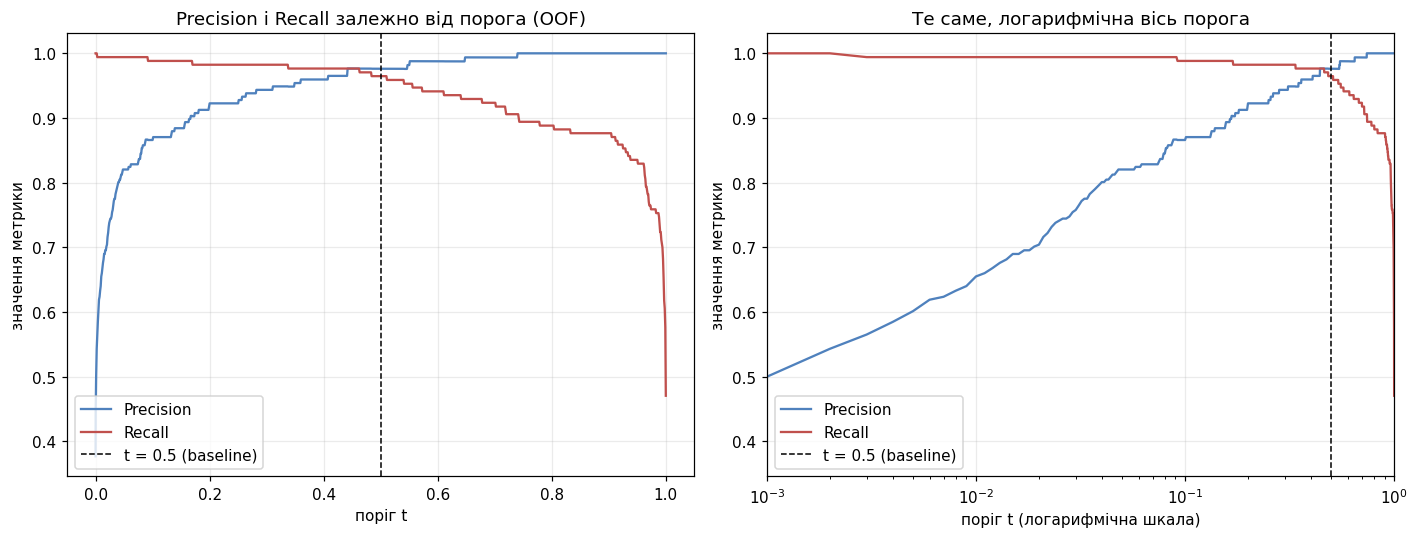

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, logx in zip(axes, [False, True]):
    ax.plot(TAB_RAW["threshold"], TAB_RAW["precision"], color=C_BENIGN, label="Precision")
    ax.plot(TAB_RAW["threshold"], TAB_RAW["recall"], color=C_MALIGN, label="Recall")
    ax.axvline(0.5, color="black", ls="--", lw=1, label="t = 0.5 (baseline)")
    ax.set_xlabel("поріг t" + (" (логарифмічна шкала)" if logx else ""))
    ax.set_ylabel("значення метрики")
    if logx:
        ax.set_xscale("log")
        ax.set_xlim(1e-3, 1)
        ax.set_title("Те саме, логарифмічна вісь порога")
    else:
        ax.set_title("Precision і Recall залежно від порога (OOF)")
    ax.legend(loc="lower left")
fig.tight_layout()
fig.savefig(FIG / "02_precision_recall_vs_threshold.png")
plt.show()

**Інтерпретація рис. 2.** Зі зростанням порога Precision зростає від 0,38 (за $t\to0$ це просто частка злоякісних) до 1,00 (за $t\ge0{,}8$ жодного FP), а Recall спадає:
0,994 за $t\in[0{,}02;0{,}09]$, 0,982 за $t\approx0{,}2\text{–}0{,}3$, 0,965 за $t=0{,}5$, 0,888 за $t=0{,}8$ і 0,835 за $t=0{,}95$.
Криві перетинаються поблизу $t\approx0{,}45$ (за $t=0{,}452$ маємо FP = FN = 4, Precision = Recall = 0,976).
Обидві метрики змінюються повільно в області $t\in[0{,}1;0{,}5]$ і різко — на краях. Права панель (логарифмічна вісь) показує, що область малих порогів
$10^{-3}\ldots10^{-1}$ — це та сама «плоска» ділянка Recall, де додаткові біопсії майже не додають знайдених злоякісних випадків.

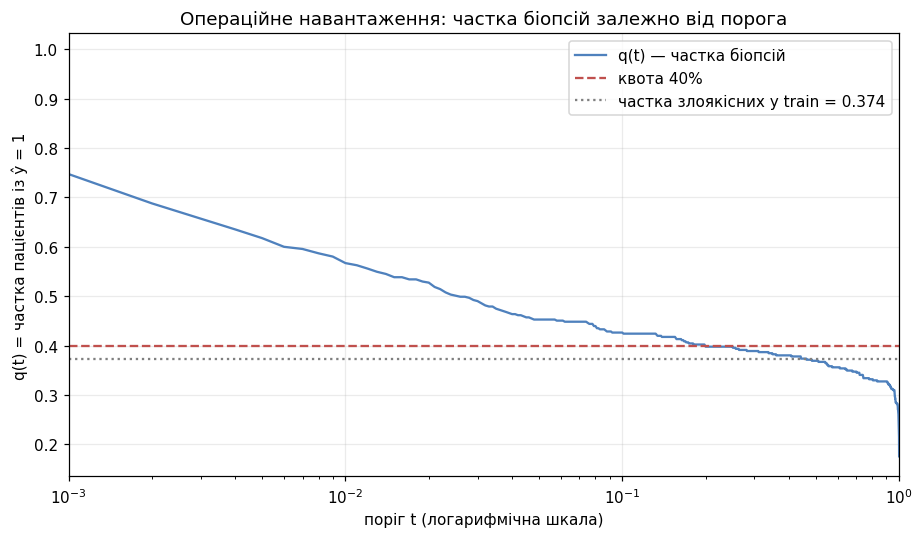

In [11]:
fig, ax = plt.subplots(figsize=(8.5, 5))
ax.plot(TAB_RAW["threshold"], TAB_RAW["q"], color=C_BENIGN, label="q(t) — частка біопсій")
ax.axhline(QUOTA, color=C_RED, ls="--", label=f"квота {QUOTA:.0%}")
ax.axhline(N_POS / N, color=C_GREY, ls=":", label=f"частка злоякісних у train = {N_POS / N:.3f}")
ax.set_xscale("log")
ax.set_xlim(1e-3, 1)
ax.set_xlabel("поріг t (логарифмічна шкала)")
ax.set_ylabel("q(t) = частка пацієнтів із ŷ = 1")
ax.set_title("Операційне навантаження: частка біопсій залежно від порога")
ax.legend()
fig.tight_layout()
fig.savefig(FIG / "03_alert_rate_vs_threshold.png")
plt.show()

**Інтерпретація рис. 3.** Частка біопсій монотонно спадає з порогом: $q=0{,}75$ за $t=10^{-3}$, 0,53 за $t=0{,}02$, 0,43 за $t=0{,}09$, 0,40 за $t\approx0{,}2$, 0,37 за $t=0{,}5$ і 0,31 за $t=0{,}95$.
Ліворуч від $t\approx0{,}2$ крива різко йде вгору — саме там порушується квота 40 %. Між $t=0{,}2$ та $t=0{,}5$ навантаження змінюється лише на ~3 п. п.
(з 398 до 369 біопсій на 1000), тобто в «середині» діапазону поріг мало впливає на навантаження, а від нього залежать лише кілька FN/FP.
Горизонтальна лінія 0,374 (частка злоякісних) показує: політика з $q$ меншим за цю частку неминуче пропускає злоякісні випадки.

### Робочі точки та два локальні компроміси

Нижче — сім змістовних робочих точок: від найагресивнішого направлення на біопсію до найконсервативнішого.

In [12]:
WORK_T = [0.02, 0.09, 0.20, 0.30, 0.50, 0.80, 0.95]
wp = pd.DataFrame([evaluate_threshold(y, S_RAW, t) for t in WORK_T]).set_index("threshold")
wp["біопсій на 1000"] = (1000 * wp["q"]).round(0)
print(wp[["tp", "fp", "fn", "tn", "precision", "recall", "q", "біопсій на 1000"]].round(3).to_string())


def tradeoff(t_from, t_to):
    a, b = evaluate_threshold(y, S_RAW, t_from), evaluate_threshold(y, S_RAW, t_to)
    d_fn, d_fp, d_act = b["fn"] - a["fn"], b["fp"] - a["fp"], (b["tp"] + b["fp"]) - (a["tp"] + a["fp"])
    print(f"t: {t_from} -> {t_to}:  ΔFN = {d_fn:+d},  ΔFP = {d_fp:+d},  Δбіопсій = {d_act:+d} (з {N})", end="")
    if d_fn != 0:
        print(f"  => ціна зміни ≈ {abs(d_fp / d_fn):.1f} FP на 1 FN")
    else:
        print()


print()
tradeoff(0.5, 0.09)     # компроміс 1: зниження порога
tradeoff(0.09, 0.02)    # компроміс 2: ще нижче
tradeoff(0.5, 0.95)     # компроміс 3: підвищення порога

            tp  fp  fn   tn  precision  recall      q  біопсій на 1000
threshold                                                             
0.02       169  71   1  214      0.704   0.994  0.527            527.0
0.09       169  26   1  259      0.867   0.994  0.429            429.0
0.20       167  14   3  271      0.923   0.982  0.398            398.0
0.30       167  10   3  275      0.944   0.982  0.389            389.0
0.50       164   4   6  281      0.976   0.965  0.369            369.0
0.80       151   0  19  285      1.000   0.888  0.332            332.0
0.95       142   0  28  285      1.000   0.835  0.312            312.0

t: 0.5 -> 0.09:  ΔFN = -5,  ΔFP = +22,  Δбіопсій = +27 (з 455)  => ціна зміни ≈ 4.4 FP на 1 FN
t: 0.09 -> 0.02:  ΔFN = +0,  ΔFP = +45,  Δбіопсій = +45 (з 455)
t: 0.5 -> 0.95:  ΔFN = +22,  ΔFP = -4,  Δбіопсій = -26 (з 455)  => ціна зміни ≈ 0.2 FP на 1 FN


**Два локальні компроміси.** Робочі точки: 0,02 — максимальна чутливість; 0,09 — оптимум реалістичного сценарію без обмеження; 0,20 — межа квоти ($q\approx0{,}398$);
0,30 — середина допустимої зони; 0,50 — baseline; 0,80 — нуль FP; 0,95 — «лише найвпевненіші».

1. **Зниження порога з 0,5 до 0,09.** Знаходимо на 5 злоякісних більше (FN: 6 → 1), але платимо 22 додатковими зайвими біопсіями (FP: 4 → 26); усього +27 біопсій
   (+59 на 1000 пацієнтів). Ціна ≈ 4,4 FP за один врятований FN. Якщо пропуск злоякісного коштує понад 4,4 зайвих біопсій, це вигідно; у контрольному сценарії ($c_{FN}/c_{FP}=1$) — ні.
   Водночас $q$ піднімається з 0,369 до 0,429 — понад квоту.
2. **Подальше зниження з 0,09 до 0,02.** FN не змінюється (залишається 1: єдиний пропущений злоякісний випадок має бал 0,0021, нижче за всі ці пороги), зате +45 зайвих біопсій — «чиста» втрата.
   Це приклад, коли нижчий поріг не купує нічого: вигоди закінчилися, а витрати лишились.

(Для порівняння: підвищення з 0,5 до 0,95 дає −4 FP, але +22 FN — невигідний обмін за будь-якого $c_{FN}/c_{FP}$, більшого за ≈0,2.)

## 6. Порівняння сценаріїв вартості

Для кожного сценарію знаходимо **емпіричний мінімум** $C(t)$ за OOF-прогнозами. Оскільки функція вартості кускова-стала (змінюється лише
там, де поріг проходить через бал якогось об'єкта), мінімум часто досягається на **плато**. Правило вибору (моє рішення — його можна змінити):
серед усіх порогів сітки з мінімальною вартістю беремо **медіану за порогом** — середину плато, а не його край. Край плато лежить впритул
до балу конкретного об'єкта, і мінімальний зсув розподілу балів змінив би рішення; середина стійкіша. Межі плато виводяться окремо.

In [13]:
def pick(cost, q, grid, quota=None):
    # Найкращий допустимий поріг. quota=None -> без обмеження; інакше допустимі лише q(t) <= quota.
    cost = np.asarray(cost, float)
    feasible = np.ones(len(cost), bool) if quota is None else (np.asarray(q) <= quota + 1e-12)
    if not feasible.any():
        return None
    masked = np.where(feasible, cost, np.inf)
    best = masked.min()
    tied = np.flatnonzero(masked <= best + 1e-12)
    i = int(tied[len(tied) // 2])                    # середина плато мінімальної вартості
    return {"i": i, "t": float(grid[i]), "cost": float(best),
            "t_lo": float(grid[tied.min()]), "t_hi": float(grid[tied.max()]), "n_tied": int(len(tied))}


def scenario_summary(tab, y_true, score, quota=None):
    rows = []
    for name, r in SCENARIOS.items():
        c = pick(tab[f"cost_{name}"], tab["q"], tab["threshold"].to_numpy(), quota)
        row = tab.iloc[c["i"]]
        ts = threshold_table(y_true, score, np.array([T_STAR[name]])).iloc[0]       # вартість точно в теоретичному t*
        rows.append({
            "сценарій": SC_UA[name], "t*": T_STAR[name], "t_min(емп.)": c["t"],
            "плато": f"[{c['t_lo']:.3f}; {c['t_hi']:.3f}]",
            "FP": int(row.fp), "FN": int(row.fn), "Precision": row.precision, "Recall": row.recall,
            "q": row.q, "C/n": c["cost"], "C/n у t*": ts[f"cost_{name}"], "q>квоти": bool(row.q > QUOTA),
        })
    return pd.DataFrame(rows)


SUM_RAW = scenario_summary(TAB_RAW, y, S_RAW)
print("Необмежений мінімум C(t) на OOF (сирий бал логістичної регресії):")
print(SUM_RAW.round(4).to_string(index=False))

Необмежений мінімум C(t) на OOF (сирий бал логістичної регресії):
         сценарій     t*  t_min(емп.)          плато  FP  FN  Precision  Recall      q    C/n  C/n у t*  q>квоти
  контрольний (1) 0.5000        0.452 [0.442; 0.462]   4   4     0.9765  0.9765 0.3736 0.0176    0.0220    False
реалістичний (10) 0.0909        0.090 [0.088; 0.091]  26   1     0.8667  0.9941 0.4286 0.0791    0.0791     True
   стресовий (50) 0.0196        0.090 [0.088; 0.091]  26   1     0.8667  0.9941 0.4286 0.1670    0.2659     True


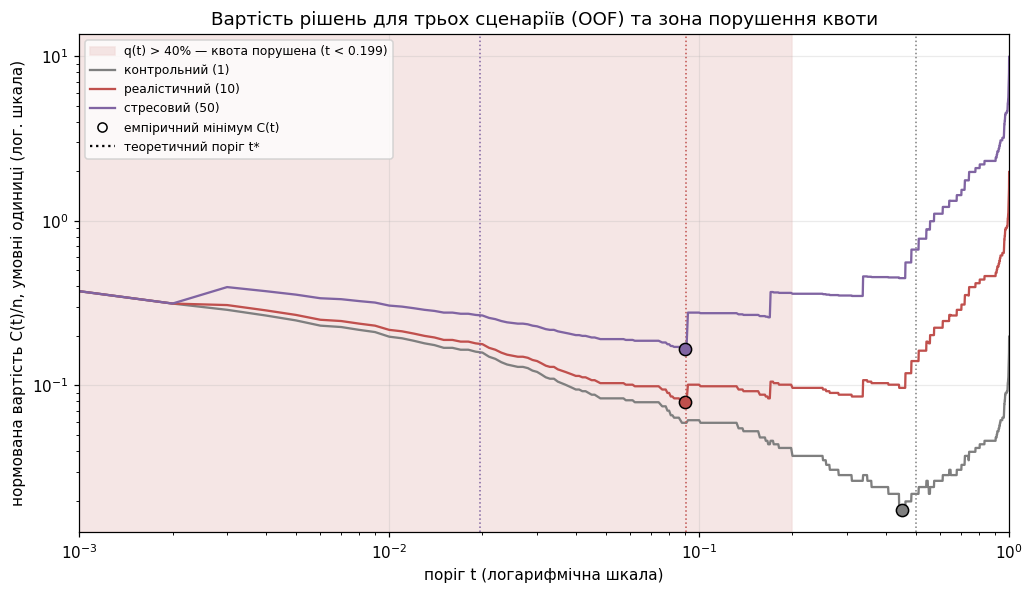

In [14]:
fig, ax = plt.subplots(figsize=(9.5, 5.5))
t_feas = float(TAB_RAW.loc[TAB_RAW["q"] <= QUOTA, "threshold"].min())      # q(t) монотонно спадає за t
ax.axvspan(1e-3, t_feas, color="#f2dcdb", alpha=0.7, label=f"q(t) > {QUOTA:.0%} — квота порушена (t < {t_feas:.3f})")
for name in SCENARIOS:
    ax.plot(TAB_RAW["threshold"], TAB_RAW[f"cost_{name}"], color=SC_COLOR[name], label=f"{SC_UA[name]}")
    c = pick(TAB_RAW[f"cost_{name}"], TAB_RAW["q"], GRID)
    ax.plot(c["t"], c["cost"], "o", color=SC_COLOR[name], ms=8, mec="black")
    ax.axvline(T_STAR[name], color=SC_COLOR[name], ls=":", lw=1)
ax.plot([], [], "o", color="white", mec="black", label="емпіричний мінімум C(t)")
ax.plot([], [], ":", color="black", label="теоретичний поріг t*")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim(1e-3, 1)
ax.set_xlabel("поріг t (логарифмічна шкала)")
ax.set_ylabel("нормована вартість C(t)/n, умовні одиниці (лог. шкала)")
ax.set_title("Вартість рішень для трьох сценаріїв (OOF) та зона порушення квоти")
ax.legend(fontsize=8, loc="upper left")
fig.tight_layout()
fig.savefig(FIG / "04_cost_curves_scenarios.png")
plt.show()

**Інтерпретація рис. 4 і таблиці сценаріїв.** Усі три криві починаються в одній точці ($t\to0$: усіх направлено, FN = 0, $C/n=FP/n\approx0{,}62$ — частка доброякісних).
Чим дорожчий FN, тим вище й крутіше права гілка кривої (пропущені злоякісні) і тим лівіше мінімум. Контрольна крива має мінімум біля $t\approx0{,}45$;
реалістична і стресова — біля $t\approx0{,}09$.
Червона заливка — область $t<0{,}199$, де $q>40\,\%$: **обидва «дорогі» мінімуми лежать у забороненій зоні**.

| Сценарій | $t^*$ | $t_{min}$ (плато) | FP / FN | Precision / Recall | $q$ | $C/n$ у $t_{min}$ | $C/n$ у $t^*$ |
|---|---|---|---|---|---|---|---|
| контрольний (1) | 0,500 | 0,452 [0,442; 0,462] | 4 / 4 | 0,976 / 0,976 | 0,374 | 0,0176 | 0,0220 |
| реалістичний (10) | 0,091 | 0,090 [0,088; 0,091] | 26 / 1 | 0,867 / 0,994 | 0,429 | 0,0791 | 0,0791 |
| стресовий (50) | 0,020 | 0,090 [0,088; 0,091] | 26 / 1 | 0,867 / 0,994 | 0,429 | 0,1670 | 0,2659 |

**Теоретичний проти емпіричного порога.** Контрольний: емпіричний мінімум трохи лівіше $t^*=0{,}5$ (4 FN замість 6 за ціну тих самих 4 FP); різниця — у межах одного-двох об'єктів.
Реалістичний: формальний збіг ($0{,}090$ проти $0{,}091$), але **він не є доказом калібрування**: плато [0,088; 0,091] обмежене двома конкретними об'єктами (доброякісний 0,0878 і злоякісний 0,0915), і саме злоякісний об'єкт із балом 0,0915 визначає емпіричний оптимум для **будь-якого** $r\ge9$ (навіть за $r=20$, де $t^*=0{,}048$), тоді як для $r=6\ldots8$ ($t^*=0{,}14\ldots0{,}11$) емпіричний оптимум — 0,337. Збіг при $r=10$ випадковий; про калібрування судимо за діаграмою надійності в розділі 8, а вона в зоні 0,10–0,30 показує скоріше переоцінку ризику (прогноз 0,184 проти фактичних 0,059). Стресовий: $t^*=0{,}02$ **не підтверджується** емпірично:
у $t^*$ вартість на 59 % вища за мінімум (0,2659 проти 0,1670), бо зниження порога з 0,09 до 0,02 додає 45 FP без жодного знайденого FN (єдиний недосяжний злоякісний випадок має бал 0,0021).
Формула $t^*$ припускає калібровану оцінку ризику саме в області малих ймовірностей, а перевірити це на 46 об'єктах (розділ 8) неможливо. Різні сценарії дають різні рішення,
бо змінюється ціна одного FN відносно одного FP: контрольний допускає 4 FN при 4 FP, реалістичний/стресовий — 1 FN ціною 26 FP. Стресовий не відрізняється від реалістичного,
тому що в даних більше немає досяжних FN, які можна «купити» додатковими біопсіями.

## 7. Ресурсне обмеження

**Обмеження:** не більше **40 %** пацієнтів за період може бути направлено на біопсію ($q(t)\le 0{,}40$). Це **жорстка квота місткості**
(слоти на core-needle біопсію/радіологів), а не м'який орієнтир: понад квоту система не може фізично виконати процедури в цьому періоді.
Обмеження відповідає процесу: воно стосується саме дії, яку запускає $\hat y=1$.

Додатково зауважте: частка злоякісних у навчальній вибірці ≈ 37 %, тобто навіть ідеальний класифікатор використає майже всю квоту.
Місткість 40 % залишає лише ~2–3 процентні пункти «запасу» на зайві біопсії. Чи справді квота обмежує рішення — перевіряємо для кожного сценарію.

**Реалізація жорсткої квоти (top-k).** Для пакета з $n$ пацієнтів $k=\lfloor 0{,}40\cdot n\rfloor$.
Правило: застосувати поріг; якщо біопсій більше за $k$ — залишити $k$ пацієнтів із **найвищими** балами, решту перевести **на один рівень нижче**
(`manual_review`: повторна FNA/консиліум), а не відкинути. Тобто квота — це *стеля*, а не обов'язок заповнити $k$ місць.
**Ties:** при рівних балах першим іде об'єкт із меншим індексом (порядок надходження) — стабільне сортування за ключем `(-score, index)`;
результат відтворюваний. **Переповнення черги** фіксується в журналі (кількість переведених і їхні бали), що є сигналом для моніторингу.
Реалізація — `select_top_k`, `capacity_k`, `DecisionPolicy.decide_batch_with_quota` у `policy/decision_policy.py` (розділ 11).

In [15]:
def row_summary(label, tab_row):
    return {"політика": label, "t": tab_row["threshold"], "FP": int(tab_row.fp), "FN": int(tab_row.fn),
            "Precision": tab_row.precision, "Recall": tab_row.recall, "q": tab_row.q}


rows = []
for name, r in SCENARIOS.items():
    unc = pick(TAB_RAW[f"cost_{name}"], TAB_RAW["q"], GRID)
    con = pick(TAB_RAW[f"cost_{name}"], TAB_RAW["q"], GRID, quota=QUOTA)
    base_row = evaluate_threshold(y, S_RAW, T_BASE)
    base_cost = (C_FP * base["fp"] + r * C_FP * base["fn"]) / N
    for label, c in [("без обмеження", unc), (f"квота ≤{QUOTA:.0%}", con)]:
        rr = TAB_RAW.iloc[c["i"]]
        d = row_summary(label, rr)
        d.update({"сценарій": SC_UA[name], "C/n": c["cost"], "квота діє": bool(con["i"] != unc["i"])})
        rows.append(d)
    d = {"політика": "baseline t=0.5", "t": T_BASE, "FP": base["fp"], "FN": base["fn"], "Precision": base["precision"],
         "Recall": base["recall"], "q": base["q"], "сценарій": SC_UA[name], "C/n": base_cost, "квота діє": False}
    rows.append(d)
cmp7 = pd.DataFrame(rows)[["сценарій", "політика", "t", "FP", "FN", "Precision", "Recall", "q", "C/n", "квота діє"]]
print(cmp7.round(4).to_string(index=False))

n_k = dp.capacity_k(N, QUOTA)
print(f"\nk = floor({QUOTA} * {N}) = {n_k} біопсій на OOF-вибірку")
feas = TAB_RAW[TAB_RAW["q"] <= QUOTA]
print(f"Допустимі пороги (q<=квоти): t >= {feas.threshold.min():.3f}  ({len(feas)} з {GRID.size} точок сітки)")

         сценарій       політика     t  FP  FN  Precision  Recall      q    C/n  квота діє
  контрольний (1)  без обмеження 0.452   4   4     0.9765  0.9765 0.3736 0.0176      False
  контрольний (1)     квота ≤40% 0.452   4   4     0.9765  0.9765 0.3736 0.0176      False
  контрольний (1) baseline t=0.5 0.500   4   6     0.9762  0.9647 0.3692 0.0220      False
реалістичний (10)  без обмеження 0.090  26   1     0.8667  0.9941 0.4286 0.0791       True
реалістичний (10)     квота ≤40% 0.324   9   3     0.9489  0.9824 0.3868 0.0857       True
реалістичний (10) baseline t=0.5 0.500   4   6     0.9762  0.9647 0.3692 0.1407      False
   стресовий (50)  без обмеження 0.090  26   1     0.8667  0.9941 0.4286 0.1670       True
   стресовий (50)     квота ≤40% 0.324   9   3     0.9489  0.9824 0.3868 0.3495       True
   стресовий (50) baseline t=0.5 0.500   4   6     0.9762  0.9647 0.3692 0.6681      False

k = floor(0.4 * 455) = 182 біопсій на OOF-вибірку
Допустимі пороги (q<=квоти): t >= 0.199

In [16]:
# Реалізація top-k на OOF-балах: k найвищих балів, ties — за порядком об'єктів
top_idx = dp.select_top_k(S_RAW, n_k)
t_k = S_RAW[top_idx[-1]]                          # бал k-го за рангом об'єкта = еквівалентний поріг
print(f"k={n_k}: найнижчий бал у вибраних = {t_k:.5f}; частка = {len(top_idx) / N:.4f}")
print("Унікальних балів:", np.unique(S_RAW).size, "з", N, "-> у OOF ties немає; у продукційних даних (округлені бали) вони можливі,")
print("тому порядок розв'язується за індексом об'єкта (див. тести test_equal_scores_tie_by_object_order).")

# Порівняння: «поріг-стеля» проти «top-k завжди заповнює квоту»
c_con = pick(TAB_RAW["cost_realistic"], TAB_RAW["q"], GRID, quota=QUOTA)
mask_topk = np.zeros(N, bool)
mask_topk[top_idx] = True
fn_topk, fp_topk = int(((~mask_topk) & (y == 1)).sum()), int((mask_topk & (y == 0)).sum())
print(f"\nПоріг t={c_con['t']:.3f} (стеля): біопсій {int(TAB_RAW.iloc[c_con['i']].tp + TAB_RAW.iloc[c_con['i']].fp)}, "
      f"FP={int(TAB_RAW.iloc[c_con['i']].fp)}, FN={int(TAB_RAW.iloc[c_con['i']].fn)}, C/n={c_con['cost']:.4f}")
print(f"Top-{n_k} (завжди заповнює квоту): біопсій {mask_topk.sum()}, FP={fp_topk}, FN={fn_topk}, "
      f"C/n={(C_FP * fp_topk + SCENARIOS['realistic'] * C_FP * fn_topk) / N:.4f}")

k=182: найнижчий бал у вибраних = 0.19932; частка = 0.4000
Унікальних балів: 455 з 455 -> у OOF ties немає; у продукційних даних (округлені бали) вони можливі,
тому порядок розв'язується за індексом об'єкта (див. тести test_equal_scores_tie_by_object_order).

Поріг t=0.324 (стеля): біопсій 176, FP=9, FN=3, C/n=0.0857
Top-182 (завжди заповнює квоту): біопсій 182, FP=15, FN=3, C/n=0.0989


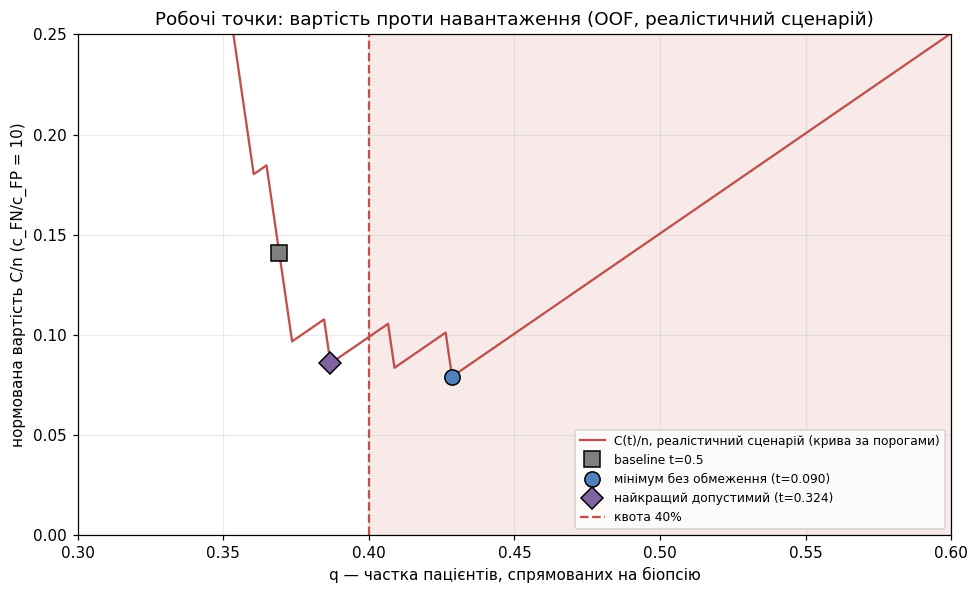

In [17]:
fig, ax = plt.subplots(figsize=(9, 5.5))
ax.plot(TAB_RAW["q"], TAB_RAW["cost_realistic"], color=C_MALIGN, lw=1.5, label="C(t)/n, реалістичний сценарій (крива за порогами)")
unc = pick(TAB_RAW["cost_realistic"], TAB_RAW["q"], GRID)
con = pick(TAB_RAW["cost_realistic"], TAB_RAW["q"], GRID, quota=QUOTA)
pts = [("baseline t=0.5", T_BASE, "s", C_GREY),
       (f"мінімум без обмеження (t={unc['t']:.3f})", unc["t"], "o", C_BENIGN),
       (f"найкращий допустимий (t={con['t']:.3f})", con["t"], "D", C_PURPLE)]
for lab, t, mk, col in pts:
    r_ = threshold_table(y, S_RAW, np.array([t])).iloc[0]
    ax.plot(r_.q, r_.cost_realistic, mk, color=col, ms=10, mec="black", label=lab)
ax.axvline(QUOTA, color=C_RED, ls="--", label=f"квота {QUOTA:.0%}")
ax.axvspan(QUOTA, 0.6, color="#f2dcdb", alpha=0.6)
ax.set_xlim(0.30, 0.60)
ax.set_ylim(0.0, 0.25)
ax.set_xlabel("q — частка пацієнтів, спрямованих на біопсію")
ax.set_ylabel("нормована вартість C/n (c_FN/c_FP = 10)")
ax.set_title("Робочі точки: вартість проти навантаження (OOF, реалістичний сценарій)")
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(FIG / "05_cost_vs_alert_rate.png")
plt.show()

**Інтерпретація розділу 7 і рис. 5.** **Чи обмеження діє?** Так — для реалістичного й стресового сценаріїв, ні — для контрольного. Необмежений оптимум реалістичного сценарію ($t=0{,}09$) потребує $q=0{,}429>0{,}40$ (195 біопсій із 455, а квота — 182),
тобто квота **реально обмежує** рішення, але ненабагато: перевищення — 13 біопсій (2,9 п. п.). Для контрольного сценарію ($q=0{,}374$) квота не діє.

| Політика (реалістичний сценарій) | $t$ | FP | FN | Precision | Recall | $q$ | біопсій | $C/n$ |
|---|---|---|---|---|---|---|---|---|
| baseline | 0,500 | 4 | 6 | 0,976 | 0,965 | 0,369 | 168 | 0,1407 |
| мінімум без обмеження (порушує квоту) | 0,090 | 26 | 1 | 0,867 | 0,994 | 0,429 | 195 | 0,0791 |
| **найкращий допустимий (квота ≤ 40 %)** | **0,324** | 9 | 3 | 0,949 | 0,982 | 0,387 | 176 | **0,0857** |

Квота змінила рішення: допустимі пороги — $t\ge0{,}199$; серед них мінімум вартості на плато [0,311; 0,337] (середина — 0,324). Обмін відносно необмеженого оптимуму: −19 біопсій, −17 FP, але +2 FN, вартість +8,3 %.
Порівняно з baseline вартість нижча на 39 % (0,0857 проти 0,1407) за +8 біопсій. У стресовому сценарії те саме рішення $t=0{,}324$ коштує $C/n=0{,}3495$ проти 0,1670 без обмеження (+109 %): там квота дорого обходиться.

**Жорстка квота й top-k.** Це жорстка стеля місткості (слоти на біопсію), тому реалізується як *стеля*, а не як «завжди заповнювати квоту»: порівняння на OOF показало, що безумовний top-182 (завжди 182 біопсій) гірший за поріг-стелю
(FP = 15 проти 9 за тих самих 3 FN; $C/n$ = 0,0989 проти 0,0857). У OOF усі 455 балів унікальні, тому ties тут не виникають, але вони можливі для округлених балів у продукції — тому порядок розв'язується за індексом об'єкта.
Для нової партії поріг може дати більше за $k$ біопсій (як на test у розділі 13) — тоді діє cap: найвищі $k$ лишаються на біопсії, решта переводиться в `manual_review` з фіксацією в журналі.

## 8. Перевірка та поліпшення калібрування

Для вибору порога за формулою $t^*=c_{FP}/(c_{FP}+c_{FN})$ бал має бути ймовірністю, а для порівняння політик за вартістю —
принаймні розумно відкаліброваним у **низькій зоні** (0,02–0,3), де лежать оптимальні пороги. Перевіряємо це на чесних OOF-прогнозах.

**Схема відокремлення (без витоку).** Кожен зовнішній fold $k$ — це тестова частина; усе калібрування відбувається лише в межах навчальної частини цього fold:

```
D_train (455) ── зовнішній StratifiedKFold(5, shuffle, rs=42) ──►  fold k = {оцінювання OOF}, решта 4/5 = {Xtr}
Xtr  ── внутрішній StratifiedKFold(3) у CalibratedClassifierCV ──►  для кожного j=1..3:
         base_j  = Pipeline(scaler → LogReg).fit( Xtr без внутр. fold j )        # навчання базової моделі
         calib_j = Sigmoid.fit( base_j.predict(внутр. fold j), y[внутр. fold j] ) # навчання калібратора
OOF-бал для fold k = середнє calib_j(base_j(X_fold_k))                           # оцінювання; fold k не бачили ні base_j, ні calib_j
```

In [18]:
# Числова перевірка відокремлення на першому зовнішньому fold
tr0, va0 = next(iter(outer_cv.split(X_train, y_train)))
inner = list(StratifiedKFold(n_splits=3).split(X_train.iloc[tr0], y_train.iloc[tr0]))   # так CalibratedClassifierCV ділить Xtr при cv=3
print(f"Зовнішній fold 0: Xtr = {len(tr0)}, оцінювання = {len(va0)}")
for j, (b, c) in enumerate(inner):
    print(f"  внутрішній {j}: навчання базової моделі {len(b)}, навчання калібратора {len(c)}")
    assert set(tr0[c]).isdisjoint(va0) and set(tr0[b]).isdisjoint(va0)
print("Об'єкти зовнішнього fold не потрапляють ні в навчання базової моделі, ні в навчання калібратора: OK")

Зовнішній fold 0: Xtr = 364, оцінювання = 91
  внутрішній 0: навчання базової моделі 242, навчання калібратора 122
  внутрішній 1: навчання базової моделі 243, навчання калібратора 121
  внутрішній 2: навчання базової моделі 243, навчання калібратора 121
Об'єкти зовнішнього fold не потрапляють ні в навчання базової моделі, ні в навчання калібратора: OK


In [19]:
def ece_quantile(y_true, s, n_bins=10):
    # ECE за квантильними бінами (рівна кількість об'єктів у біні)
    edges = np.unique(np.quantile(s, np.linspace(0, 1, n_bins + 1)))
    b = np.clip(np.searchsorted(edges, s, side="right") - 1, 0, len(edges) - 2)
    ece = 0.0
    for k in range(len(edges) - 1):
        m = b == k
        if m.any():
            ece += m.mean() * abs(s[m].mean() - y_true[m].mean())
    return ece


variants = {"raw (LogReg, без калібрування)": S_RAW, "sigmoid (Platt), cv=3": S_SIG, "isotonic, cv=3 (додатково)": S_ISO}
cal_rows = []
for name, s in variants.items():
    cal_rows.append({"варіант": name, "Brier": brier_score_loss(y, s), "log-loss": log_loss(y, np.clip(s, 1e-15, 1 - 1e-15)),
                     "ROC-AUC": roc_auc_score(y, s), "ECE (10 квант. бінів)": ece_quantile(y, s)})
cal_tab = pd.DataFrame(cal_rows).set_index("варіант")
print(cal_tab.round(5).to_string())

# Парний bootstrap різниці Brier (калібрований - сирий) на тих самих OOF-об'єктах
rng = np.random.default_rng(RANDOM_STATE)
B_CAL = 2000
e_raw = (S_RAW - y) ** 2
diffs = {}
for name, s in [("sigmoid", S_SIG), ("isotonic", S_ISO)]:
    d_i = (s - y) ** 2 - e_raw
    boots = np.array([d_i[rng.integers(0, N, N)].mean() for _ in range(B_CAL)])
    diffs[name] = (d_i.mean(), *np.percentile(boots, [2.5, 97.5]))
    print(f"ΔBrier ({name} − raw) = {diffs[name][0]:+.5f}, 95% bootstrap ІД [{diffs[name][1]:+.5f}; {diffs[name][2]:+.5f}]")

                                  Brier  log-loss  ROC-AUC  ECE (10 квант. бінів)
варіант                                                                          
raw (LogReg, без калібрування)  0.01856   0.07232  0.99542                0.01062
sigmoid (Platt), cv=3           0.02392   0.09995  0.99515                0.04162
isotonic, cv=3 (додатково)      0.01986   0.13627  0.99284                0.00590
ΔBrier (sigmoid − raw) = +0.00537, 95% bootstrap ІД [+0.00298; +0.00759]
ΔBrier (isotonic − raw) = +0.00130, 95% bootstrap ІД [-0.00108; +0.00384]


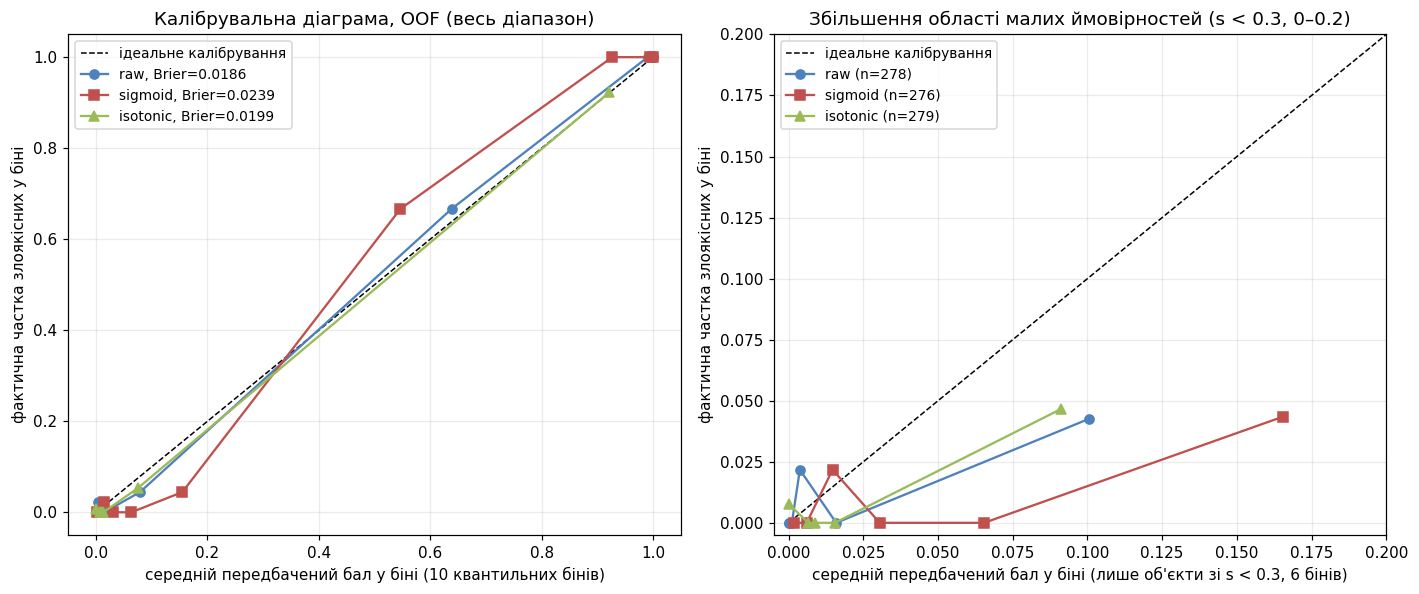

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
styles = [("raw", S_RAW, C_BENIGN, "o"), ("sigmoid", S_SIG, C_MALIGN, "s"), ("isotonic", S_ISO, "#9bbb59", "^")]

ax = axes[0]
ax.plot([0, 1], [0, 1], "k--", lw=1, label="ідеальне калібрування")
for lab, s, col, mk in styles:
    frac, mean_pred = calibration_curve(y, s, n_bins=10, strategy="quantile")
    ax.plot(mean_pred, frac, marker=mk, color=col, label=f"{lab}, Brier={brier_score_loss(y, s):.4f}")
ax.set_xlabel("середній передбачений бал у біні (10 квантильних бінів)")
ax.set_ylabel("фактична частка злоякісних у біні")
ax.set_title("Калібрувальна діаграма, OOF (весь діапазон)")
ax.legend(fontsize=9)

ax = axes[1]
mask = S_RAW < 0.3
ax.plot([0, 0.2], [0, 0.2], "k--", lw=1, label="ідеальне калібрування")
for lab, s, col, mk in styles:
    m = s < 0.3
    frac, mean_pred = calibration_curve(y[m], s[m], n_bins=6, strategy="quantile")
    ax.plot(mean_pred, frac, marker=mk, color=col, label=f"{lab} (n={int(m.sum())})")
ax.set_xlim(-0.005, 0.2)
ax.set_ylim(-0.005, 0.2)
ax.set_xlabel("середній передбачений бал у біні (лише об'єкти зі s < 0.3, 6 бінів)")
ax.set_ylabel("фактична частка злоякісних у біні")
ax.set_title("Збільшення області малих ймовірностей (s < 0.3, 0–0.2)")
ax.legend(fontsize=9)
fig.tight_layout()
fig.savefig(FIG / "06_reliability_diagram.png")
plt.show()

In [21]:
# Області переоцінювання / недооцінювання ризику: фіксовані діапазони балу
edges = [0, 0.02, 0.10, 0.30, 0.70, 0.95, 1.0000001]
rows = []
for lab, s in [("raw", S_RAW), ("sigmoid", S_SIG)]:
    for lo, hi in zip(edges[:-1], edges[1:]):
        m = (s >= lo) & (s < hi)
        if m.sum() == 0:
            continue
        p_hat, p_obs = s[m].mean(), y[m].mean()
        se = np.sqrt(max(p_hat * (1 - p_hat), 1e-12) / m.sum())          # біномна похибка за p_hat
        verdict = "у межах шуму" if abs(p_obs - p_hat) <= 2 * se else ("переоцінює ризик" if p_obs < p_hat else "недооцінює ризик")
        rows.append({"бал": lab, "діапазон": f"[{lo:.2f}; {min(hi, 1):.2f})", "n": int(m.sum()), "середній бал": p_hat,
                     "фактична частка": p_obs, "різниця": p_obs - p_hat, "2·SE": 2 * se, "висновок": verdict})
print(pd.DataFrame(rows).round(4).to_string(index=False))

    бал     діапазон   n  середній бал  фактична частка  різниця   2·SE         висновок
    raw [0.00; 0.02) 215        0.0028           0.0047   0.0019 0.0072     у межах шуму
    raw [0.02; 0.10)  46        0.0429           0.0217  -0.0211 0.0597     у межах шуму
    raw [0.10; 0.30)  17        0.1837           0.0588  -0.1248 0.1878     у межах шуму
    raw [0.30; 0.70)  19        0.4971           0.5263   0.0292 0.2294     у межах шуму
    raw [0.70; 0.95)  16        0.8270           0.9375   0.1105 0.1891     у межах шуму
    raw [0.95; 1.00) 142        0.9955           1.0000   0.0045 0.0112     у межах шуму
sigmoid [0.00; 0.02) 136        0.0073           0.0074   0.0000 0.0146     у межах шуму
sigmoid [0.02; 0.10)  98        0.0493           0.0000  -0.0493 0.0437 переоцінює ризик
sigmoid [0.10; 0.30)  42        0.1723           0.0476  -0.1246 0.1165 переоцінює ризик
sigmoid [0.30; 0.70)  31        0.4881           0.6129   0.1248 0.1796     у межах шуму
sigmoid [0.70; 0.95) 

**Інтерпретація рис. 6 і таблиць калібрування.** **Показники якості ймовірностей (OOF, n = 455).**

| Варіант | Brier | log-loss | ROC-AUC | ECE (10 квантильних бінів) |
|---|---|---|---|---|
| raw (LogReg) | **0,0186** | **0,0723** | 0,9954 | 0,0106 |
| sigmoid | 0,0239 | 0,1000 | 0,9951 | 0,0416 |
| isotonic (додатково) | 0,0199 | 0,1363 | 0,9928 | 0,0059 |

Парний bootstrap різниці Brier (2000 повторів): sigmoid − raw = +0,0054, 95 % ІД [+0,0030; +0,0076] — **калібрування *погіршило* Brier достовірно**;
isotonic − raw = +0,0013, ІД [−0,0011; +0,0038] — різниця статистично незначуща, а log-loss гірший (0,136), бо ізотонічна функція дає ймовірності 0 і 1 (східчаста), які карає логарифмічна втрата.
Ізотонічна має найкращий ECE, але це не компенсує гірших Brier і log-loss.

**Де ризик переоцінений/недооцінений.** Сирий бал: у всіх діапазонах відхилення в межах 2·SE (шуму) — калібрування достатнє, хоча в областях [0,02; 0,10) (n = 46, передбачено 0,043, фактично 0,022)
та [0,10; 0,30) (n = 17, передбачено 0,184, фактично 0,059) *спостерігається тенденція до переоцінки ризику*, яку на такому обсязі не можна ні довести, ні відкинути.
Sigmoid-калібратор зсуває ймовірності: достовірно *переоцінює* ризик у [0,02; 0,10) (передбачено 0,049, фактично 0 із 98) та [0,10; 0,30) (0,172 проти 0,048), і *недооцінює* в [0,70; 0,95) (0,875 проти 1,00 при n = 42).
Причина: сигмоїда Платта має лише два параметри й навчається на ~120 об'єктах внутрішнього fold; логістична регресія вже дає «логістичні» ймовірності, тому додатковий сигмоїдний крок лише додає шум і стискає розподіл.
Перевірено розмір вибірки (n = 455, у низькій зоні 46 і 17 об'єктів), кількість бінів (10 квантильних; у збільшеній панелі — 6) і метод (sigmoid + isotonic) — висновок не залежить від цих налаштувань: калібрування не допомагає.

**Збільшена панель** (s < 0,3) наочно показує, що там менше ніж 300 об'єктів і лише 3 злоякісних — тому будь-яка калібрувальна крива в цій зоні має великий шум.

In [22]:
# Правило вибору бала фіксується ДО перегляду впливу на політику: калібрований бал замінює сирий лише якщо
# (1) Brier нижчий, (2) log-loss нижчий, (3) 95% bootstrap-ІД ΔBrier повністю нижче нуля.
def keeps_calibrated(name, s):
    return (brier_score_loss(y, s) < brier_score_loss(y, S_RAW)
            and log_loss(y, np.clip(s, 1e-15, 1 - 1e-15)) < log_loss(y, np.clip(S_RAW, 1e-15, 1 - 1e-15))
            and diffs[name][2] < 0)


use_sig, use_iso = keeps_calibrated("sigmoid", S_SIG), keeps_calibrated("isotonic", S_ISO)
print("sigmoid замінює raw:", use_sig, "| isotonic замінює raw:", use_iso)
if use_sig:
    SCORE_NAME, SCORE_COL, S_FINAL = "calibrated_sigmoid", "score_calibrated", S_SIG
elif use_iso:
    SCORE_NAME, SCORE_COL, S_FINAL = "calibrated_isotonic", "score_isotonic", S_ISO
else:
    SCORE_NAME, SCORE_COL, S_FINAL = "raw_logreg_proba", "score_raw", S_RAW
print("ВИБРАНИЙ БАЛ ДЛЯ ПОЛІТИКИ:", SCORE_NAME)

sigmoid замінює raw: False | isotonic замінює raw: False
ВИБРАНИЙ БАЛ ДЛЯ ПОЛІТИКИ: raw_logreg_proba


### Пороги до й після калібрування

Для кожного варіанта бала повторюємо вибір порога (без обмеження й із квотою). Вартість порівнянна між варіантами,
бо обчислюється для тих самих $y$ на тих самих OOF-об'єктах.

In [23]:
rows = []
for vname, s in [("raw", S_RAW), ("sigmoid", S_SIG), ("isotonic", S_ISO)]:
    tab = threshold_table(y, s, GRID)
    for name in SCENARIOS:
        unc = pick(tab[f"cost_{name}"], tab["q"], GRID)
        con = pick(tab[f"cost_{name}"], tab["q"], GRID, quota=QUOTA)
        ru, rc = tab.iloc[unc["i"]], tab.iloc[con["i"]]
        rows.append({"бал": vname, "сценарій": SC_UA[name], "t* (теор.)": T_STAR[name],
                     "t_min": unc["t"], "q(t_min)": ru.q, "C/n": unc["cost"],
                     "t (квота)": con["t"], "q(квота)": rc.q, "C/n (квота)": con["cost"]})
cmp8 = pd.DataFrame(rows)
print(cmp8.round(4).to_string(index=False))

     бал          сценарій  t* (теор.)  t_min  q(t_min)    C/n  t (квота)  q(квота)  C/n (квота)
     raw   контрольний (1)      0.5000  0.452    0.3736 0.0176      0.452    0.3736       0.0176
     raw реалістичний (10)      0.0909  0.090    0.4286 0.0791      0.324    0.3868       0.0857
     raw    стресовий (50)      0.0196  0.090    0.4286 0.1670      0.324    0.3868       0.3495
 sigmoid   контрольний (1)      0.5000  0.409    0.3736 0.0176      0.409    0.3736       0.0176
 sigmoid реалістичний (10)      0.0909  0.185    0.4264 0.0769      0.346    0.3868       0.0857
 sigmoid    стресовий (50)      0.0196  0.185    0.4264 0.1648      0.346    0.3868       0.3495
isotonic   контрольний (1)      0.5000  0.502    0.3626 0.0242      0.502    0.3626       0.0242
isotonic реалістичний (10)      0.0909  0.314    0.3846 0.0835      0.314    0.3846       0.0835
isotonic    стресовий (50)      0.0196  0.032    0.4791 0.2176      0.314    0.3846       0.3473


**Висновок щодо калібрування і вибору бала.** Правило, зафіксоване *до* порівняння: калібрований варіант замінює сирий бал, лише якщо в нього нижчі і Brier, і log-loss, а 95 % bootstrap-ІД різниці Brier лежить повністю нижче нуля. Ні sigmoid, ні isotonic цього не виконують,
тому **для політики використовується сирий бал `predict_proba` логістичної регресії (`raw_logreg_proba`)**. Рішення прийнято за OOF-даними, тестова вибірка не використовувалась.
*Це відрізняється від початкового припущення методички, де калібрований OOF-бал вважається основним; результат на цих даних протилежний.*

**Вибір порогів до й після калібрування.** Необмежений оптимум реалістичного сценарію залежить від калібрування: 0,090 (raw), 0,185 (sigmoid), 0,314 (isotonic) — різні $t$ за майже однакової вартості (0,0791 / 0,0769 / 0,0835).
Натомість **із квотою** пороги близькі (0,324 / 0,346 / 0,314) і дають майже однакову вартість (0,0857 / 0,0857 / 0,0835), а кількість біопсій становить 176 / 176 / 175. Отже, ресурсна
квота робить остаточне рішення значно менш залежним від калібрування, ніж необмежений мінімум. (Нижча вартість isotonic на 0,002 — це 1 пацієнт із 455, тобто в межах шуму.)
Для контрольного сценарію пороги (0,452 / 0,409 / 0,502) відрізняються на кілька об'єктів.

## 9. Аналіз чутливості рішення

З цього розділу використовується бал, вибраний у розділі 8 (`S_FINAL`). Фіксуємо основні величини політики:
* **основний сценарій** — реалістичний ($c_{FN}/c_{FP}=10$) із жорсткою квотою $q\le 40\%$;
* $t_{low}$ — емпіричний оптимум **без** обмеження (початок «значущого ризику»);
* $t_{c}$ — найкращий допустимий поріг **з** квотою (однопорогова робоча точка).

In [24]:
TAB = threshold_table(y, S_FINAL, GRID)
PRED = (S_FINAL[:, None] >= GRID[None, :]).astype(float)       # N x T, для швидкого bootstrap

RATIO_MAIN = SCENARIOS["realistic"]
c_unc = pick(TAB["cost_realistic"], TAB["q"], GRID)
c_con = pick(TAB["cost_realistic"], TAB["q"], GRID, quota=QUOTA)
T_UNC, T_C = c_unc["t"], c_con["t"]
I_C = c_con["i"]
row_c = TAB.iloc[I_C]
print(f"Бал: {SCORE_NAME}")
print(f"Без обмеження: t_low = {T_UNC:.4f}, плато [{c_unc['t_lo']:.3f}; {c_unc['t_hi']:.3f}], q = {TAB.iloc[c_unc['i']].q:.4f}, C/n = {c_unc['cost']:.4f}")
print(f"З квотою:      t_c   = {T_C:.4f}, плато [{c_con['t_lo']:.3f}; {c_con['t_hi']:.3f}], q = {row_c.q:.4f}, C/n = {c_con['cost']:.4f}")
print(f"  FP = {int(row_c.fp)}, FN = {int(row_c.fn)}, TP = {int(row_c.tp)}, TN = {int(row_c.tn)}, "
      f"Precision = {row_c.precision:.3f}, Recall = {row_c.recall:.3f}")

# Чутливість до відношення c_FN/c_FP: 1 ... 100 (логарифмічна сітка)
RATIOS = np.unique(np.concatenate([np.round(10 ** np.linspace(0, 2, 21), 3), [50.0]]))
sens = []
for r in RATIOS:
    cost_r = (C_FP * TAB["fp"] + r * C_FP * TAB["fn"]).to_numpy() / N
    u = pick(cost_r, TAB["q"], GRID)
    c = pick(cost_r, TAB["q"], GRID, quota=QUOTA)
    sens.append({"ratio": r, "t_star": 1 / (1 + r), "t_unconstrained": u["t"], "q_unconstrained": TAB.iloc[u["i"]].q,
                 "t_quota": c["t"], "q_quota": TAB.iloc[c["i"]].q, "cost_quota": c["cost"],
                 "fp_quota": int(TAB.iloc[c["i"]].fp), "fn_quota": int(TAB.iloc[c["i"]].fn)})
SENS = pd.DataFrame(sens)
SENS.to_csv(RES / "sensitivity_ratio.csv", index=False)
print()
print(SENS.round(4).to_string(index=False))

Бал: raw_logreg_proba
Без обмеження: t_low = 0.0900, плато [0.088; 0.091], q = 0.4286, C/n = 0.0791
З квотою:      t_c   = 0.3240, плато [0.311; 0.337], q = 0.3868, C/n = 0.0857
  FP = 9, FN = 3, TP = 167, TN = 276, Precision = 0.949, Recall = 0.982

  ratio  t_star  t_unconstrained  q_unconstrained  t_quota  q_quota  cost_quota  fp_quota  fn_quota
  1.000  0.5000            0.452           0.3736    0.452   0.3736      0.0176         4         4
  1.259  0.4427            0.452           0.3736    0.452   0.3736      0.0199         4         4
  1.585  0.3868            0.452           0.3736    0.452   0.3736      0.0227         4         4
  1.995  0.3339            0.452           0.3736    0.452   0.3736      0.0263         4         4
  2.512  0.2847            0.452           0.3736    0.452   0.3736      0.0309         4         4
  3.162  0.2403            0.452           0.3736    0.452   0.3736      0.0366         4         4
  3.981  0.2008            0.452           0.3736

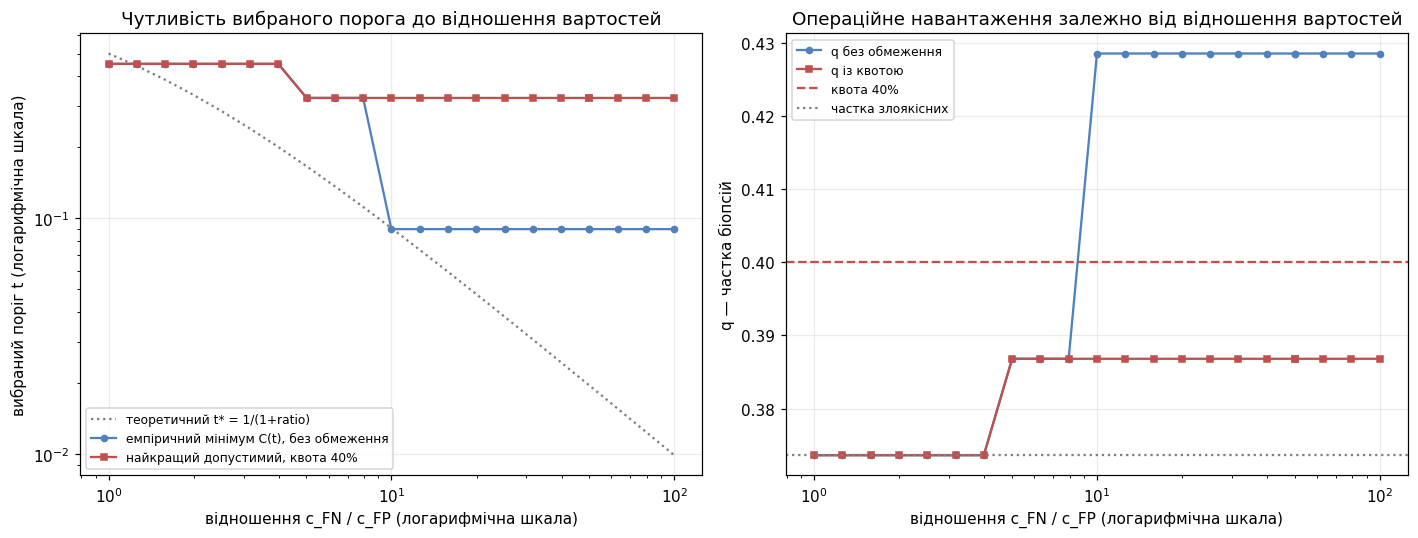

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
ax = axes[0]
ax.plot(SENS["ratio"], SENS["t_star"], ":", color=C_GREY, label="теоретичний t* = 1/(1+ratio)")
ax.plot(SENS["ratio"], SENS["t_unconstrained"], "o-", color=C_BENIGN, ms=4, label="емпіричний мінімум C(t), без обмеження")
ax.plot(SENS["ratio"], SENS["t_quota"], "s-", color=C_MALIGN, ms=4, label=f"найкращий допустимий, квота {QUOTA:.0%}")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("відношення c_FN / c_FP (логарифмічна шкала)")
ax.set_ylabel("вибраний поріг t (логарифмічна шкала)")
ax.set_title("Чутливість вибраного порога до відношення вартостей")
ax.legend(fontsize=8)

ax = axes[1]
ax.plot(SENS["ratio"], SENS["q_unconstrained"], "o-", color=C_BENIGN, ms=4, label="q без обмеження")
ax.plot(SENS["ratio"], SENS["q_quota"], "s-", color=C_MALIGN, ms=4, label="q із квотою")
ax.axhline(QUOTA, color=C_RED, ls="--", label=f"квота {QUOTA:.0%}")
ax.axhline(N_POS / N, color=C_GREY, ls=":", label="частка злоякісних")
ax.set_xscale("log")
ax.set_xlabel("відношення c_FN / c_FP (логарифмічна шкала)")
ax.set_ylabel("q — частка біопсій")
ax.set_title("Операційне навантаження залежно від відношення вартостей")
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(FIG / "07_sensitivity_ratio.png")
plt.show()

**Інтерпретація рис. 7.** Теоретична лінія $t^*=1/(1+r)$ монотонно спадає. Емпіричний необмежений поріг (синя) ступінчастий і лише три значення: 0,452 для $r\le4$, 0,324 для $r\in[5;8]$ і 0,090 для $r\ge10$.
Зміни відбуваються при $r=5$ (4 FP + 4 FN проти 9 FP + 3 FN: рівність за $4+4r=9+3r$) та $r=8{,}5$ (9 FP + 3 FN проти 26 FP + 1 FN). Тобто саме значення $r=10$ лежить лише трохи за межею $r=8{,}5$, а емпіричний поріг для $r=10$ спирається на обмін 17 FP
на 2 FN (вигода — 3 умовні одиниці з 39).

**З квотою** ступінь залежності від $r$ набагато менша: поріг 0,452 для $r<5$ і **постійний 0,324 для всіх $r\in[5;100]$**. На правій панелі видно чому: необмежений оптимум для $r\ge10$ має $q=0{,}429$ (понад квоту), а допустима політика застрягає на $q=0{,}387$.
Висновок: за жорсткої квоти подальше збільшення ціни FN понад $r\approx5$ не змінює ні поріг, ні навантаження — рішення визначає не $r$, а місткість і якість ранжування (див. також стресовий сценарій).
Цінність мають лише зміна місткості, поява нових даних/ознак або заміна самого ранжування.

### Перевірка стійкості: майже рівноцінний діапазон і bootstrap

1. **Майже рівноцінний діапазон:** пороги, для яких $C(t)\le 1{,}01\cdot\min C$ (серед допустимих за квотою).
2. **Bootstrap OOF-прогнозів:** 500 повторів вибірки пар $(y_i, s_i)$ з поверненням (`np.random.default_rng(42)`); у кожному повторі знову
   вибираємо оптимальний допустимий поріг (та без обмеження). Додатково оцінюємо **жаль** (regret) від використання *фіксованого* $t_c$:
   на скільки відсотків вартість $t_c$ перевищує оптимум цього bootstrap-повтору.

In [26]:
# 1) майже рівноцінний діапазон
cost_main = TAB["cost_realistic"].to_numpy()
feas = TAB["q"].to_numpy() <= QUOTA + 1e-12
near_q = feas & (cost_main <= 1.01 * c_con["cost"] + 1e-12)
near_u = cost_main <= 1.01 * c_unc["cost"] + 1e-12
print(f"Майже рівноцінний діапазон (C ≤ 1.01·min) із квотою:  t ∈ [{GRID[near_q].min():.3f}; {GRID[near_q].max():.3f}]  ({near_q.sum()} порогів сітки)")
print(f"Майже рівноцінний діапазон без обмеження:           t ∈ [{GRID[near_u].min():.3f}; {GRID[near_u].max():.3f}]  ({near_u.sum()} порогів сітки)")

# практично незмінний діапазон: допустимі пороги з вартістю не більше +10% / +25% від мінімуму
for lim in (1.10, 1.25):
    ok = feas & (cost_main <= lim * c_con["cost"] + 1e-12)
    print(f"Допустимі пороги з C ≤ {lim:.2f}·min: t ∈ [{GRID[ok].min():.3f}; {GRID[ok].max():.3f}]")
probe_t = [0.20, 0.25, 0.30, T_C, 0.35, 0.40, 0.45, 0.50, 0.60]
pt = threshold_table(y, S_FINAL, np.array(probe_t))
pt["біопсій з 455"] = (pt["tp"] + pt["fp"]).astype(int)
print(pt[["threshold", "fp", "fn", "q", "біопсій з 455", "cost_realistic"]].round(4).to_string(index=False))
# які об'єкти обмежують плато оптимуму
pos_scores = np.sort(S_FINAL[y == 1])[:5]
neg_scores = np.sort(S_FINAL[y == 0])[::-1][:6]
print("Найнижчі бали серед злоякісних (потенційні FN):", np.round(pos_scores, 4))
print("Найвищі бали серед доброякісних (потенційні FP):", np.round(neg_scores, 4))

# 2) bootstrap
rng = np.random.default_rng(RANDOM_STATE)
B_BOOT = 500
b_con, b_unc, regret, q_at_tc, q_unc_boot, oob_diff = [], [], [], [], [], []
for _ in range(B_BOOT):
    w = np.bincount(rng.integers(0, N, N), minlength=N).astype(float)
    wp, wn = w * y, w * (1 - y)
    tp, fp = wp @ PRED, wn @ PRED
    fn = wp.sum() - tp
    q = (w @ PRED) / w.sum()
    cost = (C_FP * fp + RATIO_MAIN * C_FP * fn) / w.sum()
    bc, bu = pick(cost, q, GRID, quota=QUOTA), pick(cost, q, GRID)
    b_con.append(bc["t"])
    b_unc.append(bu["t"])
    regret.append(cost[I_C] / bc["cost"] - 1 if bc["cost"] > 0 else np.nan)
    q_at_tc.append(q[I_C])
    q_unc_boot.append(q[bu["i"]])
    # out-of-bag порівняння: вартість t_c проти порога, вибраного в повторі, на об'єктах, які в повтор не потрапили
    w0 = (w == 0).astype(float)
    fp_o, tp_o = (w0 * (1 - y)) @ PRED, (w0 * y) @ PRED
    fn_o = (w0 * y).sum() - tp_o
    cost_o = (C_FP * fp_o + RATIO_MAIN * C_FP * fn_o) / w0.sum()
    oob_diff.append(cost_o[I_C] - cost_o[bc["i"]])
b_con, b_unc, regret, oob_diff = np.array(b_con), np.array(b_unc), np.array(regret), np.array(oob_diff)
pcts = [5, 25, 50, 75, 95]
print(f"\nBootstrap (B={B_BOOT}): оптимальний допустимий поріг, перцентилі {pcts}: {np.round(np.percentile(b_con, pcts), 3)}")
print(f"Bootstrap: оптимальний поріг без обмеження,         перцентилі {pcts}: {np.round(np.percentile(b_unc, pcts), 3)}")
lo_n, hi_n = GRID[near_q].min(), GRID[near_q].max()
print(f"Частка bootstrap-оптимумів, що потрапили в майже рівноцінний діапазон повної вибірки [{lo_n:.3f}; {hi_n:.3f}]: "
      f"{np.mean((b_con >= lo_n) & (b_con <= hi_n)):.2%}")
print(f"In-sample жаль фіксованого t_c (оптимізм: поріг повтору обирався на тих самих даних): медіана {np.nanmedian(regret):.1%}, "
      f"90-й перцентиль {np.nanpercentile(regret, 90):.1%}")
print(f"Out-of-bag: C/n(t_c) − C/n(поріг повтору) на об'єктах поза повтором: середнє {oob_diff.mean():+.4f}, медіана {np.median(oob_diff):+.4f}, "
      f"90-й перцентиль {np.percentile(oob_diff, 90):+.4f}; частка повторів, де t_c не гірший: {np.mean(oob_diff <= 1e-12):.1%}")
print(f"q(t_c) у bootstrap: середнє {np.mean(q_at_tc):.4f}, 5–95%: {np.round(np.percentile(q_at_tc, [5, 95]), 4)}")
print(f"Частка bootstrap-повторів, де необмежений оптимум порушує квоту (q>{QUOTA}): {np.mean(np.array(q_unc_boot) > QUOTA):.2%}")

Майже рівноцінний діапазон (C ≤ 1.01·min) із квотою:  t ∈ [0.311; 0.337]  (27 порогів сітки)
Майже рівноцінний діапазон без обмеження:           t ∈ [0.088; 0.091]  (4 порогів сітки)
Допустимі пороги з C ≤ 1.10·min: t ∈ [0.257; 0.337]
Допустимі пороги з C ≤ 1.25·min: t ∈ [0.199; 0.462]
 threshold  fp  fn      q  біопсій з 455  cost_realistic
     0.200  14   3 0.3978            181          0.0967
     0.250  14   3 0.3978            181          0.0967
     0.300  10   3 0.3890            177          0.0879
     0.324   9   3 0.3868            176          0.0857
     0.350   8   4 0.3824            174          0.1055
     0.400   7   4 0.3802            173          0.1033
     0.450   4   4 0.3736            170          0.0967
     0.500   4   6 0.3692            168          0.1407
     0.600   2  10 0.3560            162          0.2242
Найнижчі бали серед злоякісних (потенційні FN): [0.0021 0.0915 0.1692 0.3374 0.4624]
Найвищі бали серед доброякісних (потенційні FP): [0.7392 0


Bootstrap (B=500): оптимальний допустимий поріг, перцентилі [5, 25, 50, 75, 95]: [0.163 0.31  0.324 0.463 0.562]
Bootstrap: оптимальний поріг без обмеження,         перцентилі [5, 25, 50, 75, 95]: [0.087 0.09  0.168 0.324 0.463]
Частка bootstrap-оптимумів, що потрапили в майже рівноцінний діапазон повної вибірки [0.311; 0.337]: 21.80%
In-sample жаль фіксованого t_c (оптимізм: поріг повтору обирався на тих самих даних): медіана 0.0%, 90-й перцентиль 36.8%
Out-of-bag: C/n(t_c) − C/n(поріг повтору) на об'єктах поза повтором: середнє -0.0443, медіана -0.0240, 90-й перцентиль +0.0000; частка повторів, де t_c не гірший: 92.0%
q(t_c) у bootstrap: середнє 0.3875, 5–95%: [0.3495 0.4242]
Частка bootstrap-повторів, де необмежений оптимум порушує квоту (q>0.4): 53.80%


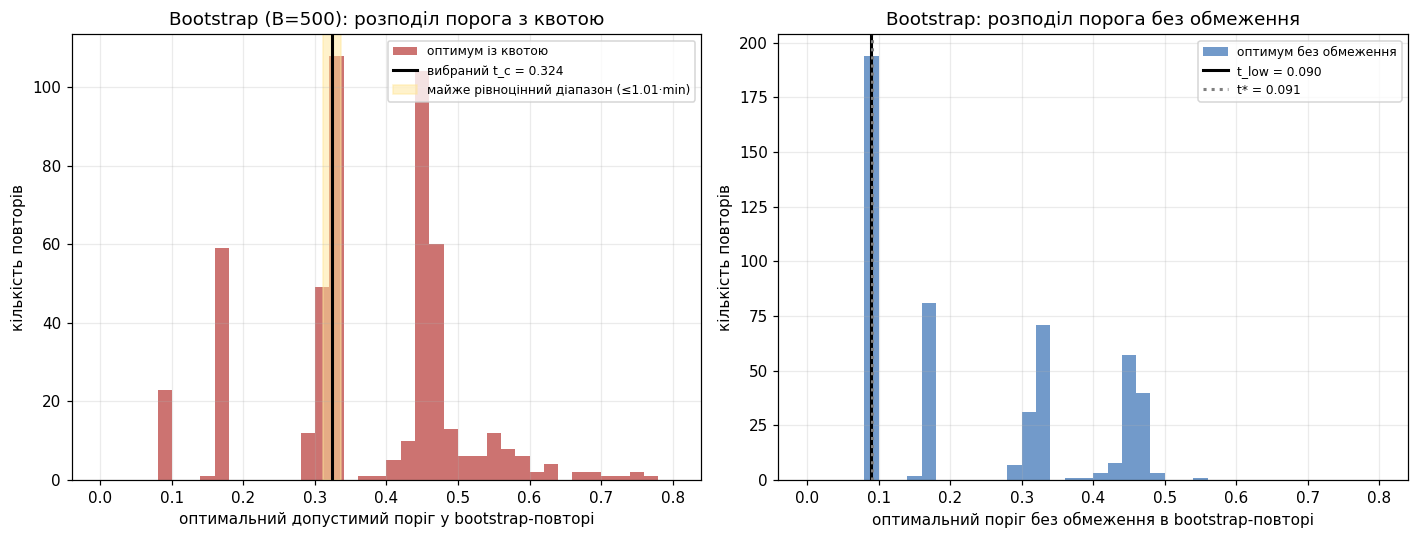

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
bins = np.linspace(0, 0.8, 41)
ax = axes[0]
ax.hist(b_con, bins=bins, color=C_MALIGN, alpha=0.8, label="оптимум із квотою")
ax.axvline(T_C, color="black", lw=2, label=f"вибраний t_c = {T_C:.3f}")
ax.axvspan(GRID[near_q].min(), GRID[near_q].max(), color="#ffe699", alpha=0.5, label="майже рівноцінний діапазон (≤1.01·min)")
ax.set_xlabel("оптимальний допустимий поріг у bootstrap-повторі")
ax.set_ylabel("кількість повторів")
ax.set_title(f"Bootstrap (B={B_BOOT}): розподіл порога з квотою")
ax.legend(fontsize=8)
ax = axes[1]
ax.hist(b_unc, bins=bins, color=C_BENIGN, alpha=0.8, label="оптимум без обмеження")
ax.axvline(T_UNC, color="black", lw=2, label=f"t_low = {T_UNC:.3f}")
ax.axvline(1 / (1 + RATIO_MAIN), color=C_GREY, ls=":", lw=2, label=f"t* = {1 / (1 + RATIO_MAIN):.3f}")
ax.set_xlabel("оптимальний поріг без обмеження в bootstrap-повторі")
ax.set_ylabel("кількість повторів")
ax.set_title("Bootstrap: розподіл порога без обмеження")
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(FIG / "08_bootstrap_threshold.png")
plt.show()

**Інтерпретація рис. 8 і стійкості.** **Майже рівноцінний діапазон.** У повній вибірці пороги з $C\le1{,}01\cdot\min C$ у межах квоти — це вузький інтервал $[0{,}311;0{,}337]$ (27 точок сітки), що відповідає одній і тій самій матриці помилок (FP = 9, FN = 3). Його межі визначають два конкретні об'єкти:
нижню — доброякісний пацієнт з балом 0,3105 (нижчий поріг додає FP), верхню — злоякісний з балом 0,3374 (вищий поріг втрачає TP). Терпимість до зсуву балів — лише ±0,013 навколо 0,324.
Ширші межі (допустимі пороги): $C\le1{,}10\cdot\min C$ при $t\in[0{,}257;0{,}337]$; $C\le1{,}25\cdot\min C$ при $t\in[0{,}199;0{,}462]$. **Практично незмінний діапазон — $t\approx0{,}20\text{–}0{,}46$** (вартість до +25 % від мінімуму; FP змінюється від 14 до 4, FN — від 3 до 4; 181 → 170 біопсій; $q\le0{,}398$).
За межами цього діапазону вартість різко зростає: $t=0{,}50$ дає FN = 6 ($C/n=0{,}141$), $t=0{,}60$ — FN = 10 ($0{,}224$).

**Bootstrap (500 повторів).** Оптимальний допустимий поріг у повторах має перцентилі 5/25/50/75/95 = 0,163 / 0,310 / **0,324** / 0,463 / 0,562; медіана збігається з вибраним $t_c$, але розподіл *мультимодальний* (піки біля 0,17, 0,32 і 0,45–0,47):
оптимум стрибає між кількома «сходинками», які створюють окремі об'єкти. У майже рівноцінний діапазон повної вибірки потрапляє лише 21,8 % bootstrap-оптимумів. Отже, **точне значення 0,324 нестійке**: його не можна подавати як «знайдений» поріг.
Необмежений оптимум також нестійкий: 0,087–0,09 приблизно у 40 % повторів, але від 0,17 до 0,46 в решті; у **53,8 %** повторів необмежений оптимум порушував би квоту.

Два зміщені оцінювачі «жалю» (втрати від використання фіксованого $t_c$ замість оптимуму повтору) обрамлюють істину: in-sample жаль завищений (поріг повтору підібрано на тих самих даних; медіана 0 %, 90-й перцентиль 37 %), а out-of-bag порівняння
занижує його (сам $t_c$ вибирався на повній вибірці, яка містить ці об'єкти; середня різниця −0,044, $t_c$ не гірший у 92 % повторів). Чесний висновок: **ширина шуму порівнянна з різницею між сусідніми порогами**; рішення про робочу *область* (0,20–0,46, 170–181 біопсій)
статистично виправдане, а вибір конкретного числа 0,324 — ні. Для звуження діапазону потрібні додаткові дані (передусім більше злоякісних випадків із балами 0,02–0,7; зараз їх лише ~12 із 170).
Частка біопсій при $t_c$ у bootstrap: середнє 0,388, 5–95 % [0,350; 0,424] — тобто в помітній частці повторів $q>0{,}40$, що додатково обґрунтовує top-k стелю замість голого порога.

## 10. Політика з ручним переглядом (три зони)

**Три дії та умови переходу** (однакові назви в коді політики та конфігурації):

| Зона | Умова | Дія |
|---|---|---|
| низька | $s < t_{low}$ | `standard_followup` — планове спостереження (контрольне УЗД через ~6 міс.) |
| середня | $t_{low}\le s < t_{high}$ | `manual_review` — повторна FNA та розгляд консиліумом |
| висока | $s \ge t_{high}$ | `biopsy` — направлення на core-needle біопсію та консультацію онколога |

**Як вибрано $t_{low}$ і $t_{high}$ (моя пропозиція, є альтернативи).**
$t_{low}=t_{min}$ — емпіричний оптимум вартості *без* обмеження (реалістичний сценарій): нижче нього навіть за ціни FN, що вдесятеро перевищує FP,
очікувана вигода від біопсії не виправдовує витрат. $t_{high}=t_c$ — найкращий допустимий поріг із квотою: вище нього біопсія виконується в межах місткості.
Отже, зона ручного перегляду — це ті пацієнти, яких вартісно-оптимальна політика направила б на біопсію, але квота не дозволяє;
замість того, щоб відкинути їх у планове спостереження, вони йдуть на дешевшу дію. Таке визначення випливає з уже зафіксованих розрахунків
(вартості + квота), а не з довільного перцентиля, і збігається з описаною поведінкою при переповненні квоти.

**Ручний перегляд — ефективність невідома.** У даних немає нічого про точність ручного перегляду, тому *не припускаємо її*:
замість цього (а) описуємо зони за даними OOF, (б) задаємо вартість переглянутого випадку $c_M$ як окремий сценарій
(у одиницях вартості біопсії; $c_M=0{,}3$ — сценарне припущення: повторна FNA + консиліум дешевші за core-needle біопсію) і (в) знаходимо
**беззбиткову точність перегляду** $a^*$: за якої симетричної точності перегляду (частка пацієнтів, яких він скеровує правильно, для обох класів)
три-зонна політика стає не гіршою за однопорогову за тією ж вартістю помилок.

In [28]:
policy3 = dp.DecisionPolicy(threshold_low=T_UNC, threshold_high=T_C)           # тимчасовий об'єкт; фінальний — із JSON (розділ 11)
act3 = np.array(policy3.decide_batch(S_FINAL))
zones = [(dp.ACTION_STANDARD, "стандартне спостереження"), (dp.ACTION_REVIEW, "ручний перегляд (повторна FNA + консиліум)"),
         (dp.ACTION_BIOPSY, "біопсія")]
rows = []
for a, ua in zones:
    m = act3 == a
    rows.append({"зона / дія": f"{a}", "опис": ua, "n": int(m.sum()), "частка": m.mean(),
                 "середній бал": S_FINAL[m].mean() if m.any() else np.nan,
                 "частка злоякісних (OOF)": y[m].mean() if m.any() else np.nan,
                 "злоякісних": int(y[m].sum()), "доброякісних": int((y[m] == 0).sum()),
                 "навантаження на 1000 пацієнтів": round(1000 * m.mean(), 1)})
ZONES = pd.DataFrame(rows)
print(ZONES.round(4).to_string(index=False))
ZONES.to_csv(RES / "three_zone_table.csv", index=False)

# Звірка з масками через пороги
assert ((act3 == dp.ACTION_BIOPSY) == (S_FINAL >= T_C)).all()
assert ((act3 == dp.ACTION_STANDARD) == (S_FINAL < T_UNC)).all()

       зона / дія                                       опис   n  частка  середній бал  частка злоякісних (OOF)  злоякісних  доброякісних  навантаження на 1000 пацієнтів
standard_followup                   стандартне спостереження 260  0.5714        0.0095                   0.0038           1           259                           571.4
    manual_review ручний перегляд (повторна FNA + консиліум)  19  0.0418        0.1855                   0.1053           2            17                            41.8
           biopsy                                    біопсія 176  0.3868        0.9303                   0.9489         167             9                           386.8


In [29]:
# Порівняння однопорогової (t_c) і три-зонної (t_low, t_c) політик за однакових припущень про вартості помилок
C_M = 0.3                                    # вартість ручного перегляду, у одиницях c_FP (сценарне припущення)
R = act3 == dp.ACTION_REVIEW
nR, PR, NR = int(R.sum()), int(y[R].sum()), int((y[R] == 0).sum())
B_ = act3 == dp.ACTION_BIOPSY
S_ = act3 == dp.ACTION_STANDARD
cost_single = (C_FP * int(((y == 0) & (S_FINAL >= T_C)).sum()) + RATIO_MAIN * C_FP * int(((y == 1) & (S_FINAL < T_C)).sum())) / N
fixed_part = (C_FP * int((y[B_] == 0).sum()) + RATIO_MAIN * C_FP * int(y[S_].sum())) / N     # помилки поза зоною перегляду


def cost_three_zone(a, c_m=C_M):
    # Перегляд скеровує правильно з імовірністю a, інакше помиляється (FN для злоякісних, FP для доброякісних)
    return fixed_part + (c_m * nR + (1 - a) * (RATIO_MAIN * C_FP * PR + C_FP * NR)) / N


def break_even(c_m):
    # a*, за якої три-зонна політика має ту саму вартість, що однопорогова
    return 1 - (RATIO_MAIN * C_FP * PR - c_m * nR) / (RATIO_MAIN * C_FP * PR + C_FP * NR)


print(f"Зона перегляду: n = {nR} ({nR / N:.2%}), злоякісних у ній {PR}, доброякісних {NR}.")
print(f"Однопорогова t_c = {T_C:.3f}: C/n = {cost_single:.4f}  (біопсій {int((S_FINAL >= T_C).sum())}, без перегляду)")
print(f"Три-зонна ({T_UNC:.3f}; {T_C:.3f}): біопсій {int(B_.sum())}, переглядів {nR}, вартість при c_M = {C_M}:")
cmp10 = pd.DataFrame({"точність перегляду a": [0.5, 0.6, 0.7, 0.8, 0.9, 1.0]})
cmp10["C/n три-зонна"] = [cost_three_zone(a) for a in cmp10["точність перегляду a"]]
cmp10["C/n однопорогова"] = cost_single
cmp10["різниця (три-зонна − одно)"] = cmp10["C/n три-зонна"] - cost_single
print(cmp10.round(4).to_string(index=False))
print("\nБеззбиткова симетрична точність перегляду a* залежно від його вартості c_M:")
print(pd.DataFrame({"c_M (у c_FP)": [0.1, 0.3, 0.5, 1.0], "a*": [break_even(c) for c in [0.1, 0.3, 0.5, 1.0]]}).round(3).to_string(index=False))
print(f"\nУвага: у зоні перегляду лише {PR} злоякісних випадків із {N_POS}; різниця ґрунтується на дуже малій кількості об'єктів.")

Зона перегляду: n = 19 (4.18%), злоякісних у ній 2, доброякісних 17.
Однопорогова t_c = 0.324: C/n = 0.0857  (біопсій 176, без перегляду)
Три-зонна (0.090; 0.324): біопсій 176, переглядів 19, вартість при c_M = 0.3:
 точність перегляду a  C/n три-зонна  C/n однопорогова  різниця (три-зонна − одно)
                  0.5         0.0949            0.0857                      0.0092
                  0.6         0.0868            0.0857                      0.0011
                  0.7         0.0787            0.0857                     -0.0070
                  0.8         0.0705            0.0857                     -0.0152
                  0.9         0.0624            0.0857                     -0.0233
                  1.0         0.0543            0.0857                     -0.0314

Беззбиткова симетрична точність перегляду a* залежно від його вартості c_M:
 c_M (у c_FP)    a*
          0.1 0.511
          0.3 0.614
          0.5 0.716
          1.0 0.973

Увага: у зоні перегляду л

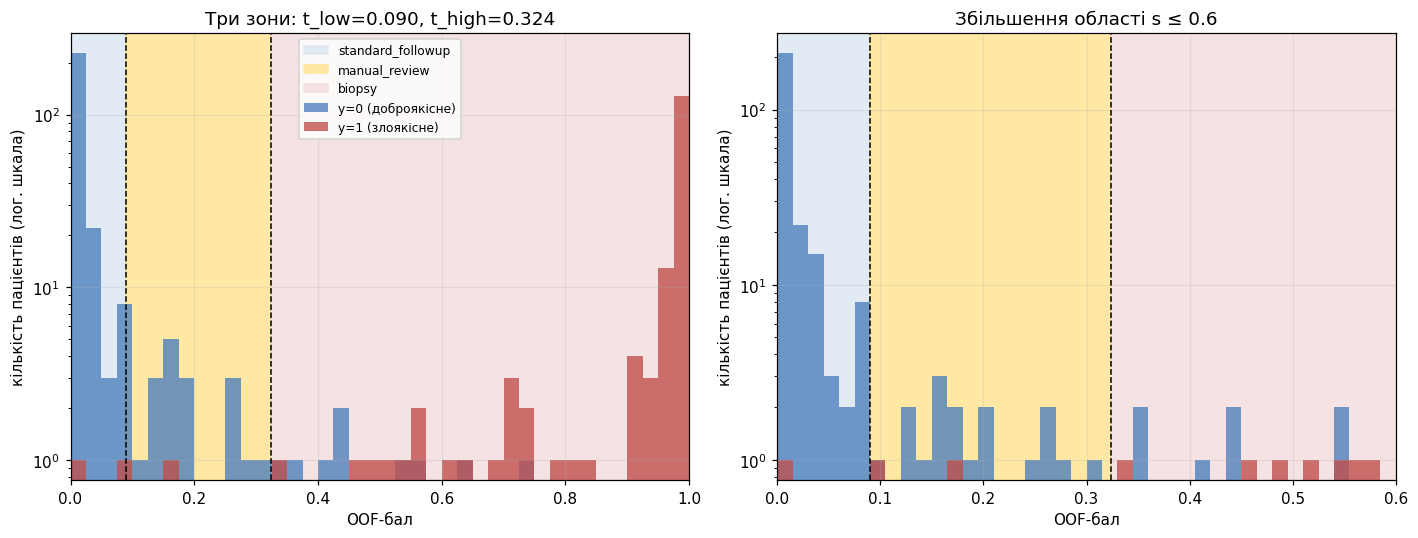

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, xmax in zip(axes, [1.0, 0.6]):
    bins = np.linspace(0, xmax, 41)
    ax.axvspan(0, T_UNC, color="#dbe5f1", alpha=0.8, label="standard_followup")
    ax.axvspan(T_UNC, T_C, color="#ffe699", alpha=0.9, label="manual_review")
    ax.axvspan(T_C, 1.0, color="#f2dcdb", alpha=0.8, label="biopsy")
    ax.hist(S_FINAL[y == 0], bins=bins, alpha=0.8, color=C_BENIGN, label="y=0 (доброякісне)")
    ax.hist(S_FINAL[y == 1], bins=bins, alpha=0.8, color=C_MALIGN, label="y=1 (злоякісне)")
    ax.axvline(T_UNC, color="black", ls="--", lw=1)
    ax.axvline(T_C, color="black", ls="--", lw=1)
    ax.set_xlim(0, xmax)
    ax.set_yscale("log")
    ax.set_xlabel("OOF-бал")
    ax.set_ylabel("кількість пацієнтів (лог. шкала)")
axes[0].set_title(f"Три зони: t_low={T_UNC:.3f}, t_high={T_C:.3f}")
axes[1].set_title("Збільшення області s ≤ 0.6")
axes[0].legend(fontsize=8, loc="upper center")
fig.tight_layout()
fig.savefig(FIG / "09_three_zones.png")
plt.show()

**Інтерпретація таблиці зон і рис. 9.** | Зона | n | частка | середній бал | частка злоякісних (OOF) | злоякісних / доброякісних | навантаження на 1000 |
|---|---|---|---|---|---|---|
| `standard_followup` ($s<0{,}090$) | 260 | 57,1 % | 0,0095 | 0,4 % | 1 / 259 | 571 |
| `manual_review` ($0{,}090\le s<0{,}324$) | 19 | 4,2 % | 0,1855 | 10,5 % | 2 / 17 | 42 |
| `biopsy` ($s\ge0{,}324$) | 176 | 38,7 % | 0,9303 | 94,9 % | 167 / 9 | 387 |

Фактична частка злоякісних зростає в тому ж порядку, що й середній бал (0,4 % → 10,5 % → 94,9 %), тобто зони змістовні. Зона перегляду мала: 19 пацієнтів (≈ 42 на 1000), з них лише 2 злоякісні — тому будь-які оцінки її ефективності ґрунтуються на двох об'єктах.
Біопсія-зона **та сама**, що й в однопороговій політиці ($t_c$), різниця лише в тому, що 19 пацієнтів із балами 0,09–0,324 замість планового спостереження отримують повторну FNA/консиліум. Два з трьох пропущених однопороговою політикою злоякісних випадків потрапляють саме в цю зону (бали 0,092 і 0,169); третій (0,002) лишається в стандартному спостереженні за будь-яких порогів.

**Порівняння за однакових припущень** ($c_{FP}=1$, $c_{FN}=10$; вартість перегляду $c_M=0{,}3$ — сценарне припущення; точність перегляду $a$ невідома і не приписується): однопорогова політика має $C/n=0{,}0857$.
Три-зонна політика *дешевша*, лише якщо $a>a^*$: беззбиткова точність $a^*=0{,}51$ за $c_M=0{,}1$; **0,61 за $c_M=0{,}3$**; 0,72 за $c_M=0{,}5$; 0,97 за $c_M=1$. Тобто за помірної вартості перегляду достатньо, щоб він правильно скеровував ≈ 61 % пацієнтів,
але якщо перегляд так само дорогий, як біопсія, він майже ніколи не виправдовується. Для $a=0{,}7/0{,}8/0{,}9/1{,}0$ три-зонна політика коштувала б 0,0787 / 0,0705 / 0,0624 / 0,0543. Оскільки даних про $a$ й $c_M$ немає, **перевага три-зонної політики не доведена**; рис. 9 і таблиця показують структуру, а не економічну перевагу.
Для реального впровадження потрібно виміряти результати перегляду (повторна FNA + консиліум) на пілотній вибірці.

## 11. Реалізація політики як компонента

Код — окремий файл `practical04/policy/decision_policy.py`: `@dataclass(frozen=True) DecisionPolicy` із `threshold_low`, `threshold_high`
(валідація `low <= high`, діапазон $[0,1]$), методами `decide(score)` і `decide_batch(scores)` (порядок результатів = порядок входу),
`decide_batch_with_quota`, а також `capacity_k` і `select_top_k` (детерміновані ties за індексом об'єкта).
**Числових порогів у коді немає** — клас читає їх із `policy_config.json` (`DecisionPolicy.from_config`).
Конфігурацію **записує цей notebook із обчислених значень** (`T_UNC`, `T_C`, `QUOTA`), тому пороги визначені в одному місці.

In [31]:
print((POL / "decision_policy.py").read_text(encoding="utf-8"))

"""Політика прийняття рішень для FNA-тріажу (Практична робота № 4).

Компонент перетворює бал моделі (оцінка ймовірності злоякісності у [0, 1])
на назву операційної дії. Числові параметри НЕ зберігаються в коді:
вони завантажуються з policy_config.json (див. DecisionPolicy.from_config).

Правило порівняння скрізь однакове: score >= threshold належить до зони вище порога.
"""
from __future__ import annotations

import json
import math
from dataclasses import dataclass
from pathlib import Path
from typing import Iterable, List, Sequence

# Назви дій (єдине джерело; notebook записує їх у конфігурацію звідси)
ACTION_STANDARD = "standard_followup"   # планове спостереження
ACTION_REVIEW = "manual_review"         # повторна FNA + консиліум
ACTION_BIOPSY = "biopsy"                # core-needle біопсія + консультація онколога

DEFAULT_CONFIG_PATH = Path(__file__).with_name("policy_config.json")


def _check_score(score) -> float:
    """Перевіряє бал: число, скінченне, у діапазоні [0, 1]."""
 

In [32]:
POLICY_DATE = "2026-09-29"
SCORE_SEMANTICS = {
    "raw_logreg_proba": "Оцінка P(malignant | ознаки): predict_proba[:, 1] логістичної регресії (StandardScaler -> LogisticRegression, C=1.0). "
                        "Додаткове sigmoid/isotonic калібрування НЕ застосовується (за OOF не покращило Brier/log-loss, розділ 8).",
    "calibrated_sigmoid": "Калібрований sigmoid-ом (CalibratedClassifierCV, cv=3) P(malignant | ознаки).",
    "calibrated_isotonic": "Калібрований ізотонічно (CalibratedClassifierCV, cv=3) P(malignant | ознаки).",
}
config = {
    "policy_id": "breast-fna-triage",
    "version": "1.0.0",
    "created": POLICY_DATE,
    "random_state": RANDOM_STATE,
    "score": {
        "name": SCORE_NAME,
        "semantics": SCORE_SEMANTICS[SCORE_NAME],
        "positive_class": "malignant (y=1)",
        "range": [0.0, 1.0],
        "comparison_rule": "score >= threshold -> дія вищої зони",
    },
    "actions": {"low": dp.ACTION_STANDARD, "middle": dp.ACTION_REVIEW, "high": dp.ACTION_BIOPSY},
    "action_descriptions": {
        dp.ACTION_STANDARD: "планове спостереження, контрольне УЗД через ~6 місяців",
        dp.ACTION_REVIEW: "повторна FNA та розгляд консиліумом",
        dp.ACTION_BIOPSY: "направлення на core-needle біопсію та консультацію онколога",
    },
    "active_variant": "single_threshold",
    "policy_variants": {
        "single_threshold": {"threshold_low": float(T_C), "threshold_high": float(T_C),
                             "note": "однопорогова політика: зона manual_review порожня"},
        "three_zone": {"threshold_low": float(T_UNC), "threshold_high": float(T_C),
                       "note": "кандидат: зона manual_review = [t_low, t_high); ефективність перегляду невідома"},
    },
    "cost_scenario": {
        "name": "realistic", "c_fp": C_FP, "c_fn": RATIO_MAIN * C_FP, "ratio_cfn_cfp": RATIO_MAIN,
        "c_manual_review": C_M, "unit": "1 умовна одиниця = вартість однієї зайвої біопсії",
        "nature": "сценарні (експертні) припущення навчального завдання, не фактичні вартості",
    },
    "constraint": {
        "type": "hard_capacity_quota", "action": dp.ACTION_BIOPSY, "max_share": QUOTA,
        "implementation": "k = floor(max_share * n_batch); якщо біопсій > k, лишаються k найвищих балів (ties: менший індекс першим)",
        "overflow": "надлишок переводиться на дію manual_review і логується",
    },
    "parameter_source": {
        "predictions": "OOF-прогнози на D_train: StratifiedKFold(5, shuffle=True, random_state=42)",
        "score_decision": "вибір бала за OOF Brier/log-loss/bootstrap (розділ 8), не за test",
        "split": "train_test_split(test_size=0.2, stratify=target, random_state=42), як у практичній № 1",
        "selection_rule": "мінімум C(t) за реалістичним сценарієм серед порогів із q(t) <= max_share; при ties — середина плато",
    },
}
(POL / "policy_config.json").write_text(json.dumps(config, ensure_ascii=False, indent=2), encoding="utf-8")
print((POL / "policy_config.json").read_text(encoding="utf-8"))

{
  "policy_id": "breast-fna-triage",
  "version": "1.0.0",
  "created": "2026-09-29",
  "random_state": 42,
  "score": {
    "name": "raw_logreg_proba",
    "semantics": "Оцінка P(malignant | ознаки): predict_proba[:, 1] логістичної регресії (StandardScaler -> LogisticRegression, C=1.0). Додаткове sigmoid/isotonic калібрування НЕ застосовується (за OOF не покращило Brier/log-loss, розділ 8).",
    "positive_class": "malignant (y=1)",
    "range": [
      0.0,
      1.0
    ],
    "comparison_rule": "score >= threshold -> дія вищої зони"
  },
  "actions": {
    "low": "standard_followup",
    "middle": "manual_review",
    "high": "biopsy"
  },
  "action_descriptions": {
    "standard_followup": "планове спостереження, контрольне УЗД через ~6 місяців",
    "manual_review": "повторна FNA та розгляд консиліумом",
    "biopsy": "направлення на core-needle біопсію та консультацію онколога"
  },
  "active_variant": "single_threshold",
  "policy_variants": {
    "single_threshold": {
      "

In [33]:
# Завантажуємо політику з файлу й перевіряємо, що вона відтворює розрахункові маски
POLICY = dp.DecisionPolicy.from_config(POL / "policy_config.json")
POLICY3 = dp.DecisionPolicy.from_config(POL / "policy_config.json", variant="three_zone")
print("Активна політика:", POLICY)
print("Три-зонна:       ", POLICY3)
acts = POLICY.decide_batch(S_FINAL)
assert np.array_equal(np.array(acts) == dp.ACTION_BIOPSY, S_FINAL >= T_C)
assert POLICY3.decide_batch(S_FINAL) == policy3.decide_batch(S_FINAL)
print("Приклади:", {s: POLICY3.decide(s) for s in [0.001, T_UNC, 0.2, T_C, 0.99]})

Активна політика: DecisionPolicy(threshold_low=0.324, threshold_high=0.324, action_low='standard_followup', action_mid='manual_review', action_high='biopsy')
Три-зонна:        DecisionPolicy(threshold_low=0.09, threshold_high=0.324, action_low='standard_followup', action_mid='manual_review', action_high='biopsy')
Приклади: {0.001: 'standard_followup', 0.09: 'manual_review', 0.2: 'manual_review', 0.324: 'biopsy', 0.99: 'biopsy'}


## 12. Тестування політики

Файл `policy/test_decision_policy.py` (unittest) перевіряє: (1) бал нижче $t_{low}$; (2) бал $=t_{low}$; (3) бал між порогами; (4) бал $=t_{high}$;
(5) бал вище $t_{high}$; (6) значення поза допустимим діапазоном (і некоректний тип); (7) порушення $t_{low}\le t_{high}$; (8) пакет прогнозів зі збереженням порядку.
Для top-k: порожня партія, партія менша за $k$, однакові бали, відтворюваний порядок ties; додатково — квота з переповненням і зчитування конфігурації.

**Команда запуску** (з каталогу `practical04/policy`):

```
python -m unittest -v test_decision_policy.py
```

In [34]:
import os
env = dict(os.environ, PYTHONIOENCODING="utf-8")
res = subprocess.run([sys.executable, "-m", "unittest", "-v", "test_decision_policy.py"],
                     cwd=POL, capture_output=True, text=True, encoding="utf-8", env=env)
print(res.stdout)
print(res.stderr)      # unittest пише звіт у stderr; тут він виведений у stdout-потік ноутбука
print("returncode =", res.returncode)
assert res.returncode == 0


test_8_batch_preserves_order (test_decision_policy.TestBatch.test_8_batch_preserves_order) ... ok
test_8_empty_batch (test_decision_policy.TestBatch.test_8_empty_batch) ... ok
test_batch_rejects_bad_element (test_decision_policy.TestBatch.test_batch_rejects_bad_element) ... ok
test_policy_from_config_matches_json (test_decision_policy.TestConfig.test_policy_from_config_matches_json) ... ok
test_empty_batch_with_quota (test_decision_policy.TestQuota.test_empty_batch_with_quota) ... ok
test_no_overflow_keeps_decisions (test_decision_policy.TestQuota.test_no_overflow_keeps_decisions) ... ok
test_overflow_demotes_lowest_scores_with_stable_ties (test_decision_policy.TestQuota.test_overflow_demotes_lowest_scores_with_stable_ties) ... ok
test_batch_smaller_than_k (test_decision_policy.TestTopK.test_batch_smaller_than_k) ... ok
test_capacity_k (test_decision_policy.TestTopK.test_capacity_k) ... ok
test_empty_batch (test_decision_policy.TestTopK.test_empty_batch) ... ok
test_equal_scores_tie_b

## 13. Фінальне оцінювання

### 13.1 Запис рішення (до відкриття $D_{test}$)

Нижче фіксується рішення **до** будь-якого застосування моделі до $D_{test}$. До цього моменту $D_{test}$ використано лише для створення
split-а (розмір, частка класів); модель на ньому не застосовувалась. Очікуваний діапазон навантаження для партії розміром $n_{test}=114$ оцінюється
bootstrap-ом з OOF (з поверненням, розмір 114): так враховується шум малої вибірки.

In [35]:
n_test = len(X_test)
rng = np.random.default_rng(RANDOM_STATE)
exp = []
for _ in range(2000):
    idx = rng.integers(0, N, n_test)
    pr = PRED[idx, I_C].astype(bool)
    yy = y[idx]
    fp_, fn_ = int((pr & (yy == 0)).sum()), int((~pr & (yy == 1)).sum())
    exp.append((pr.mean(), fp_, fn_, (C_FP * fp_ + RATIO_MAIN * C_FP * fn_) / n_test, int(((pr) & (yy == 1)).sum()) / max(int(yy.sum()), 1)))
exp = pd.DataFrame(exp, columns=["q", "fp", "fn", "cost", "recall"])
exp_range = exp.quantile([0.05, 0.5, 0.95])
print("Очікування для партії n=114 (bootstrap з OOF, поріг t_c):")
print(exp_range.round(4).to_string())

record = {
    "written_before_test_opened": True,
    "model": "Pipeline(StandardScaler -> LogisticRegression(C=1.0, max_iter=5000, random_state=42)), навчання на всій D_train",
    "score": SCORE_NAME,
    "calibration": "не застосовується (за OOF не покращило Brier/log-loss)" if SCORE_NAME == "raw_logreg_proba" else SCORE_NAME,
    "policy": {"variant": "single_threshold", "threshold": float(T_C), "rule": "score >= threshold",
               "quota": f"hard cap k = floor({QUOTA} * n_batch) на біопсії; надлишок -> manual_review (top-k за балом)"},
    "cost_matrix": {"TN": 0, "TP": 0, "FP": C_FP, "FN": RATIO_MAIN * C_FP, "scenario": "realistic (сценарна гіпотеза)"},
    "candidate_three_zone": {"threshold_low": float(T_UNC), "threshold_high": float(T_C), "c_manual_review": C_M},
    "metrics_to_compute": ["матриця помилок", "Precision", "Recall", "q", "Brier", "ROC-AUC", "вартість C/n у 3 сценаріях", "розподіл по зонах"],
    "expected_oof": {"q": float(row_c.q), "precision": float(row_c.precision), "recall": float(row_c.recall),
                     "cost": float(c_con["cost"]), "fp": int(row_c.fp), "fn": int(row_c.fn)},
    "expected_range_n114_5_95": {k: [float(exp_range.loc[0.05, k]), float(exp_range.loc[0.95, k])] for k in ["q", "cost", "fp", "fn"]},
}
(RES / "decision_record.json").write_text(json.dumps(record, ensure_ascii=False, indent=2), encoding="utf-8")
print("\nЗАПИС РІШЕННЯ (збережено в results/decision_record.json):")
print(json.dumps(record, ensure_ascii=False, indent=2))
TEST_OPENED = False

Очікування для партії n=114 (bootstrap з OOF, поріг t_c):


           q   fp   fn    cost  recall
0.05  0.3158  0.0  0.0  0.0088  0.9459
0.50  0.3860  2.0  1.0  0.0877  0.9800
0.95  0.4649  5.0  2.0  0.2105  1.0000

ЗАПИС РІШЕННЯ (збережено в results/decision_record.json):
{
  "written_before_test_opened": true,
  "model": "Pipeline(StandardScaler -> LogisticRegression(C=1.0, max_iter=5000, random_state=42)), навчання на всій D_train",
  "score": "raw_logreg_proba",
  "calibration": "не застосовується (за OOF не покращило Brier/log-loss)",
  "policy": {
    "variant": "single_threshold",
    "threshold": 0.324,
    "rule": "score >= threshold",
    "quota": "hard cap k = floor(0.4 * n_batch) на біопсії; надлишок -> manual_review (top-k за балом)"
  },
  "cost_matrix": {
    "TN": 0,
    "TP": 0,
    "FP": 1.0,
    "FN": 10.0,
    "scenario": "realistic (сценарна гіпотеза)"
  },
  "candidate_three_zone": {
    "threshold_low": 0.09,
    "threshold_high": 0.324,
    "c_manual_review": 0.3
  },
  "metrics_to_compute": [
    "матриця помилок",
  

**Запис рішення.** Зафіксовано до відкриття $D_{test}$ (файл `results/decision_record.json`):

* **Модель:** `Pipeline(StandardScaler → LogisticRegression(C=1.0, max_iter=5000, random_state=42))`, навчена на всій $D_{train}$ (455 об'єктів).
* **Бал і калібрування:** сирий `predict_proba[:, 1]`; sigmoid/isotonic калібрування **не** застосовується (OOF-докази — розділ 8).
* **Правило:** $\hat y=1\iff s\ge t_c=0{,}324$ (однопорогова політика) + жорстка квота: у партії з $n$ пацієнтів не більше $k=\lfloor0{,}40\,n\rfloor$ біопсій (top-k за балом, ties за індексом); надлишок → `manual_review`.
  Для $n_{test}=114$: $k=45$.
* **Матриця вартостей:** TN = TP = 0; FP = 1; FN = 10 (реалістичний сценарій; контрольний і стресовий лише інформативно). Усі вартості сценарні.
* **Обмеження:** $q\le0{,}40$ (жорстка квота біопсій).
* **Метрики, що будуть обчислені:** матриця помилок, Precision, Recall, F1, $q$, Brier, ROC-AUC, $C/n$ в усіх трьох сценаріях, розподіл по зонах для кандидатної три-зонної політики ($t_{low}=0{,}090$, $t_{high}=0{,}324$, описово).
* **Очікування (OOF):** $q=0{,}387$, Precision 0,949, Recall 0,982, FP = 9, FN = 3, $C/n=0{,}0857$.
* **Очікуваний діапазон для партії $n=114$** (bootstrap з OOF, 5–95 %; медіана): $q\in[0{,}316;0{,}465]$ (0,386); FP 0–5 (2); FN 0–2 (1); $C/n\in[0{,}009;0{,}211]$ (0,088). Діапазон широкий, бо в тестовій вибірці лише 42 злоякісних.

### 13.2 Одноразове оцінювання на $D_{test}$

Навчаємо `Pipeline` на всій $D_{train}$, застосовуємо **зафіксовану** політику до $D_{test}$ **один раз**. Поріг не підбирається за тестовими мітками.

In [36]:
assert TEST_OPENED is False
TEST_OPENED = True                                        # від цього моменту D_test відкрито; код нижче виконується один раз

final_model = clone(pipe).fit(X_train, y_train)
assert list(final_model.classes_) == [0, 1]
s_test = final_model.predict_proba(X_test)[:, 1]          # бал: ймовірність злоякісного
yt = y_test.to_numpy()

# ОСНОВНЕ оцінювання = політика, задекларована в записі рішення: поріг + жорстка квота top-k (k = floor(0.40 * n))
k_test = dp.capacity_k(len(yt), QUOTA)
acts_thr = POLICY.decide_batch(s_test)                     # лише діагностика: поріг без квоти
acts_t = POLICY.decide_batch_with_quota(s_test, QUOTA)     # політика із файлу конфігурації + квота
yhat_thr = (np.array(acts_thr) == dp.ACTION_BIOPSY).astype(int)
yhat_t = (np.array(acts_t) == dp.ACTION_BIOPSY).astype(int)   # ŷ=1 <=> біопсія; demoted -> manual_review рахується як ŷ=0
n_biopsy_thr, n_biopsy_cap = int(yhat_thr.sum()), int(yhat_t.sum())
assert n_biopsy_cap <= k_test, "квота порушена"
demoted = [i for i, (a, b) in enumerate(zip(acts_thr, acts_t)) if a != b]
assert all(acts_t[i] == dp.ACTION_REVIEW for i in demoted)   # demoted не відправлені додому, а йдуть на manual_review
tn_, fp_, fn_, tp_ = confusion_matrix(yt, yhat_t, labels=[0, 1]).ravel()


def costs_of(fp, fn, n):
    return {name: float((C_FP * fp + r * C_FP * fn) / n) for name, r in SCENARIOS.items()}


test_res = {
    "TN": int(tn_), "FP": int(fp_), "FN": int(fn_), "TP": int(tp_),
    "precision": precision_score(yt, yhat_t, zero_division=0), "recall": recall_score(yt, yhat_t, zero_division=0),
    "f1": f1_score(yt, yhat_t, zero_division=0), "q": yhat_t.mean(),
    "brier": brier_score_loss(yt, s_test), "roc_auc": roc_auc_score(yt, s_test),
    "cost_realistic": costs_of(fp_, fn_, len(yt))["realistic"],
    "n_biopsy_threshold_only": n_biopsy_thr, "n_biopsy_capped": n_biopsy_cap, "k": int(k_test),
}
print(f"ПОЛІТИКА (single_threshold t = {POLICY.threshold_high:.4f} + жорстка квота top-k, k = {k_test}) на D_test, "
      f"n = {len(yt)}, malignant = {int(yt.sum())}:")
print(pd.DataFrame([[tn_, fp_], [fn_, tp_]], index=["факт y=0", "факт y=1"], columns=["ŷ=0", "ŷ=1"]).to_string())
for k, v in test_res.items():
    print(f"  {k}: {v:.4f}" if isinstance(v, float) else f"  {k}: {v}")
print("  вартість C/n за сценаріями (інформативно):", {k: round(v, 4) for k, v in costs_of(fp_, fn_, len(yt)).items()})

# Квота: k = floor(0.40 * n); надлишок переведено на manual_review (не додому!)
test_res["demoted_scores"] = [round(float(s_test[i]), 6) for i in demoted]
test_res["demoted_true_class"] = [int(yt[i]) for i in demoted]
print(f"\nКвота: k = floor({QUOTA}*{len(yt)}) = {k_test}; біопсій: {n_biopsy_cap} <= k (assert пройдено). "
      f"Переведено на manual_review: {len(demoted)} (бал(и) {test_res['demoted_scores']}, фактичний клас {test_res['demoted_true_class']})")

# ДІАГНОСТИКА (не основний результат): той самий поріг без квоти
tn0, fp0, fn0, tp0 = confusion_matrix(yt, yhat_thr, labels=[0, 1]).ravel()
print(f"ДІАГНОСТИКА: поріг без квоти дав би {n_biopsy_thr} біопсій, q = {yhat_thr.mean():.4f} — тобто квота спрацювала на {n_biopsy_thr - n_biopsy_cap} пацієнта; "
      f"TN/FP/FN/TP = {tn0}/{fp0}/{fn0}/{tp0}, C/n = {costs_of(fp0, fn0, len(yt))['realistic']:.4f}")

# Три-зонна кандидатна політика (зафіксована до test)
acts3_t = np.array(POLICY3.decide_batch_with_quota(s_test, QUOTA))      # та сама жорстка квота на біопсії
rows = []
for a, ua in zones:
    m = acts3_t == a
    rows.append({"зона": a, "n": int(m.sum()), "частка": m.mean(), "середній бал": s_test[m].mean() if m.any() else np.nan,
                 "частка злоякісних": yt[m].mean() if m.any() else np.nan, "злоякісних": int(yt[m].sum())})
ZONES_TEST = pd.DataFrame(rows)
print("\nТри-зонна політика на D_test (описово):")
print(ZONES_TEST.round(4).to_string(index=False))

cmp_test = pd.DataFrame({
    "OOF (очікування)": [row_c.q, row_c.precision, row_c.recall, int(row_c.fp), int(row_c.fn), c_con["cost"],
                         brier_score_loss(y, S_FINAL), roc_auc_score(y, S_FINAL)],
    "очікуваний діапазон n=114 (5–95%)": [f"{exp_range.loc[0.05, 'q']:.3f}–{exp_range.loc[0.95, 'q']:.3f}", "", "",
                                          f"{exp_range.loc[0.05, 'fp']:.0f}–{exp_range.loc[0.95, 'fp']:.0f}",
                                          f"{exp_range.loc[0.05, 'fn']:.0f}–{exp_range.loc[0.95, 'fn']:.0f}",
                                          f"{exp_range.loc[0.05, 'cost']:.3f}–{exp_range.loc[0.95, 'cost']:.3f}", "", ""],
    "test": [test_res["q"], test_res["precision"], test_res["recall"], int(fp_), int(fn_), test_res["cost_realistic"],
             test_res["brier"], test_res["roc_auc"]],
}, index=["q", "Precision", "Recall", "FP", "FN", "C/n (реалістичний)", "Brier", "ROC-AUC"])
print("\nПорівняння з OOF:")
print(cmp_test.to_string())
def _jsonable(v):
    if isinstance(v, list):
        return v
    return v if isinstance(v, int) else float(v)


(RES / "test_results.json").write_text(json.dumps({k: _jsonable(v) for k, v in test_res.items()}, ensure_ascii=False, indent=2),
                                       encoding="utf-8")

ПОЛІТИКА (single_threshold t = 0.3240 + жорстка квота top-k, k = 45) на D_test, n = 114, malignant = 42:
          ŷ=0  ŷ=1
факт y=0   68    4
факт y=1    1   41
  TN: 68
  FP: 4
  FN: 1
  TP: 41
  precision: 0.9111
  recall: 0.9762
  f1: 0.9425
  q: 0.3947
  brier: 0.0215
  roc_auc: 0.9954
  cost_realistic: 0.1228
  n_biopsy_threshold_only: 46
  n_biopsy_capped: 45
  k: 45
  вартість C/n за сценаріями (інформативно): {'control': 0.0439, 'realistic': 0.1228, 'stress': 0.4737}

Квота: k = floor(0.4*114) = 45; біопсій: 45 <= k (assert пройдено). Переведено на manual_review: 1 (бал(и) [0.378737], фактичний клас [0])
ДІАГНОСТИКА: поріг без квоти дав би 46 біопсій, q = 0.4035 — тобто квота спрацювала на 1 пацієнта; TN/FP/FN/TP = 67/5/1/41, C/n = 0.1316

Три-зонна політика на D_test (описово):
             зона  n  частка  середній бал  частка злоякісних  злоякісних
standard_followup 58  0.5088        0.0114             0.0000           0
    manual_review 11  0.0965        0.1579           

423

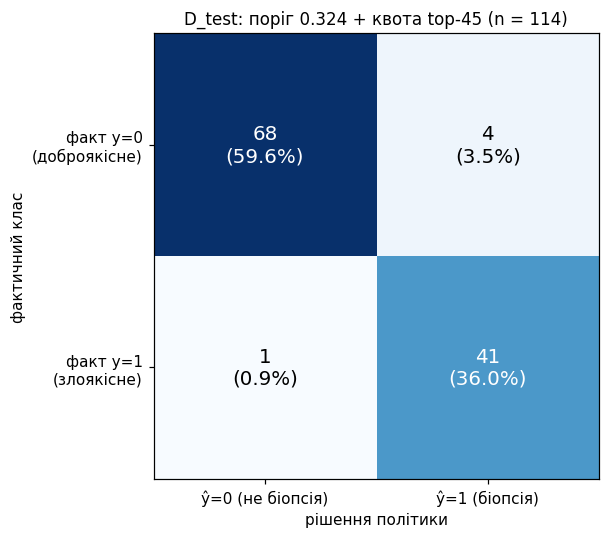

In [37]:
fig, ax = plt.subplots(figsize=(5.8, 5))
cmt = np.array([[tn_, fp_], [fn_, tp_]])
ax.imshow(cmt, cmap="Blues")
for i in range(2):
    for j in range(2):
        ax.text(j, i, f"{cmt[i, j]}\n({cmt[i, j] / len(yt):.1%})", ha="center", va="center",
                color="white" if cmt[i, j] > cmt.max() / 2 else "black", fontsize=13)
ax.set_xticks([0, 1], ["ŷ=0 (не біопсія)", "ŷ=1 (біопсія)"])
ax.set_yticks([0, 1], ["факт y=0\n(доброякісне)", "факт y=1\n(злоякісне)"])
ax.set_xlabel("рішення політики")
ax.set_ylabel("фактичний клас")
ax.set_title(f"D_test: поріг {POLICY.threshold_high:.3f} + квота top-{k_test} (n = {len(yt)})", fontsize=11)
ax.grid(False)
fig.tight_layout()
fig.savefig(FIG / "10_test_confusion_matrix.png")
plt.show()

**Аналіз результату на test.** **Основний результат — політика, задекларована в записі рішення: поріг $t=0{,}324$ + жорстка квота top-$k$ ($k=\lfloor0{,}40\cdot114\rfloor=45$), $n=114$, 42 злоякісних.**
Рішення $\hat y=1$ означає саме `biopsy`. Пацієнт, якого квота перевела з біопсії в `manual_review`, **не відправлений додому**: він іде на повторну FNA/консиліум, але в матриці помилок
рахується як $\hat y=0$ (не біопсія) — це консервативне припущення, бо результат перегляду невідомий.

| TN | FP | FN | TP | Precision | Recall | F1 | $q$ | Brier | ROC-AUC | $C/n$ (реал.) |
|---|---|---|---|---|---|---|---|---|---|---|
| 68 | 4 | 1 | 41 | 0,911 | 0,976 | 0,943 | 0,3947 (45 біопсій ≤ $k$=45) | 0,0215 | 0,9954 | 0,1228 |

**Квота.** Той самий поріг без квоти дав би 46 біопсій ($q=0{,}4035$): *квота спрацювала на одного пацієнта*. Top-$k$ cap залишив 45 найвищих балів, а одного пацієнта (бал 0,379, фактично доброякісний)
перевів на `manual_review`. Тобто політика **не порушила** свого жорсткого обмеження, а ефект cap видно саме на цьому пацієнті. (Діагностично: без cap було б TN/FP/FN/TP = 67/5/1/41, $C/n=0{,}1316$.)
Це підтверджує вибір стелі замість голого порога: поріг сам по собі не гарантує дотримання жорсткого обмеження на новій партії, а bootstrap-інтервал $q$ при $t_c$ (5–95 %: 0,350–0,424) цього й очікував.

**Порівняння з OOF-очікуванням.** Ранжування збереглося: ROC-AUC 0,9954 (OOF 0,9954), Brier 0,0215 (OOF 0,0186), Recall 0,976 (OOF 0,982), FN = 1 (очікувалося 0–2). Precision нижча (0,911 проти 0,949), бо отримано 4 FP
(очікувалося 0–5, медіана 2; OOF-масштабовано ≈ 2,3). Частка біопсій $q=0{,}395$ — у межах очікуваного діапазону 0,316–0,465 і не вище квоти. Вартість $C/n=0{,}123$ вища за OOF-оцінку 0,086, але всередині очікуваного діапазону
0,009–0,211 для партії такого розміру: різниця — це приблизно +2 FP, тобто шум малої тестової вибірки (42 злоякісних), а не доказ поломки політики. За цими даними неможливо відрізнити справжнє погіршення від флуктуації, але й суттєвого відхилення від очікування немає.

**Три-зонна кандидатна політика на test (описово, з тією ж квотою на біопсії).** Стандартне спостереження: 58 пацієнтів (50,9 %), жодного злоякісного; ручний перегляд: 11 (9,7 %), 1 злоякісний (9,1 %), серед них і пацієнт, переведений квотою;
біопсія: 45 (39,5 %), 41 злоякісний (91,1 %). Зони впорядковані так само, як в OOF (0,4 % → 10,5 % → 94,9 % там, 0 % → 9,1 % → 91,1 % тут); частка пацієнтів у зоні перегляду зросла з 4,2 % до 9,7 %.
Це лише описове підтвердження структури, а не доказ переваги — ефективність ручного перегляду так і не виміряна.

**Висновок за test.** Очікування підтверджено з урахуванням шуму: якість ранжування, Recall і структура зон збереглися; квота дотримана; відхилення (+2 FP відносно OOF-масштабу) лежать у межах очікуваного діапазону. Поріг за тестовими мітками **не змінювався**.
Наступний експеримент: збільшити кількість спостережень у «середній» зоні балів (0,1–0,6) — наприклад, зовнішнє валідаційне джерело, а не повторне розбиття цього ж набору — і виміряти результативність ручного перегляду на пілоті.

## 14. Інженерний висновок

Усі вартості — сценарні припущення; набір даних навчальний; клінічне впровадження потребує погодження з лікарями та валідації на незалежних даних.

1. **Поріг за замовчуванням (0,5).** Придатний, лише якщо пропуск злоякісного випадку коштує приблизно стільки ж, скільки зайва біопсія ($r\approx1$, $t^*=0{,}5$): тоді він близький до оптимуму (FP = 4, FN = 6, Precision 0,976, Recall 0,965).
   За $r=10$ він непридатний: 6 пропущених злоякісних проти 3 у вибраній політиці, $C/n=0{,}141$ проти 0,086 (+64 %) за +8 біопсій (168 → 176).
2. **Основний сценарій:** реалістичний, $c_{FN}/c_{FP}=10$ — експертна гіпотеза: пропуск злоякісного означає затримку діагнозу на місяці, зайва біопсія — оборотна процедура. Не виміряна величина; тому поряд аналізується $r\in[1;100]$. Точне значення 10 не є несучим: за жорсткої квоти рішення ($t=0{,}324$, 176 біопсій) **однакове для всіх $r\in[5;100]$** (розділ 9, `results/sensitivity_ratio.csv`). Отже, від експертів потрібне лише слабше твердження «пропуск злоякісного гірший щонайменше за 5 зайвих біопсій»; якщо $r<5$, політику треба переглянути (поріг 0,452).
3. **Робоча точка:** однопорогова політика $\hat y=1\iff s\ge0{,}324$ над сирим `predict_proba` логістичної регресії з top-k стелею 40 %. На OOF: FP = 9, FN = 3, Precision 0,949, Recall 0,982, $q=0{,}387$ (387 біопсій на 1000), $C/n=0{,}0857$.
4. **Вплив обмеження:** необмежений мінімум ($t=0{,}09$, 26 FP + 1 FN) потребував $q=0{,}429$ — вище квоти 0,40; квота перемістила поріг на 0,324: −19 біопсій (−42 на 1000), −17 FP, +2 FN, вартість +8,3 %. У стресовому сценарії квота обходиться в +109 %.
   За жорсткої квоти поріг не залежить від $r$ у діапазоні $[5;100]$ — рішення визначає місткість.
5. **Калібрування:** сирий бал достатньо відкалібрований (Brier 0,0186, ECE 0,011; усі відхилення в межах шуму), sigmoid його достовірно погіршив (+0,0054), isotonic не дав переваги. Застереження: в області малих ймовірностей (0,02–0,3), де лежать необмежені оптимуми, лише 63 об'єкти
   (2 злоякісних), тому формулу $t^*$ для стресового сценарію емпірично не підтверджено.
6. **Стійкість:** значення 0,324 нестійке (bootstrap 5–95 % = 0,16–0,56; плато [0,311; 0,337] обмежене двома об'єктами), але *область* рішення стійка: $t\in[0{,}20;0{,}46]$ — вартість до +25 % від мінімуму, 170–181 біопсій, і рішення не змінюється для $r\ge5$. Критичні відношення: $r=5$ і $r=8{,}5$ (для необмеженої політики).
7. **Ручний перегляд:** 19 пацієнтів (4,2 %, 42 на 1000), 2 злоякісні (10,5 %). Ефективність і вартість перегляду невідомі; при $c_M=0{,}3$ три-зонна політика вигідна, лише якщо перегляд скеровує правильно > 61 % пацієнтів. Перевага не доведена.
8. **Test:** політика «поріг 0,324 + квота top-45» дала TN/FP/FN/TP = 68/4/1/41, Precision 0,911, Recall 0,976, $q=0{,}395$, ROC-AUC 0,995, $C/n=0{,}123$ (OOF 0,086; очікуваний діапазон 0,009–0,211) — очікування підтверджено в межах шуму. Без квоти поріг дав би 46 біопсій ($q=0{,}4035$); cap перевів одного пацієнта на `manual_review` (не додому), і жорстка квота дотримана.
9. **Що моніторити:** (а) частку біопсій $q$ і кількість демотованих top-k пацієнтів; (б) розподіл балів, особливо частку пацієнтів у зоні 0,09–0,5; (в) частку злоякісних серед пацієнтів і калібрування в області малих ймовірностей; (г) гістологічні результати біопсій (FP/TP — швидка мітка, днів-тижнів);
   (д) виявлені на контролі через ~6 міс. пропуски (FN — мітка з великою затримкою й *селективна*: ми не бачимо істину для $\hat y=0$ без контролю); (е) результати ручного перегляду, якщо його запровадять.
10. **Коли переглядати політику:** при зміні частки злоякісних (інша популяція, скринінг), зміні місткості (квота ≠ 40 %), відношення $r$ (особливо якщо воно опуститься нижче 5 або вийде за межі 5–100), зміні обладнання/процесу оцифрування чи вибору ознак, перенавчанні моделі, суттєвому зсуві розподілу балів, а також після отримання даних про ефективність ручного перегляду.
   Також — якщо накопичиться достатньо нових даних, щоб звузити діапазон 0,20–0,46.